# Comparacion entre histogramas de numero colisiones elasticas por energia y configuracion

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math

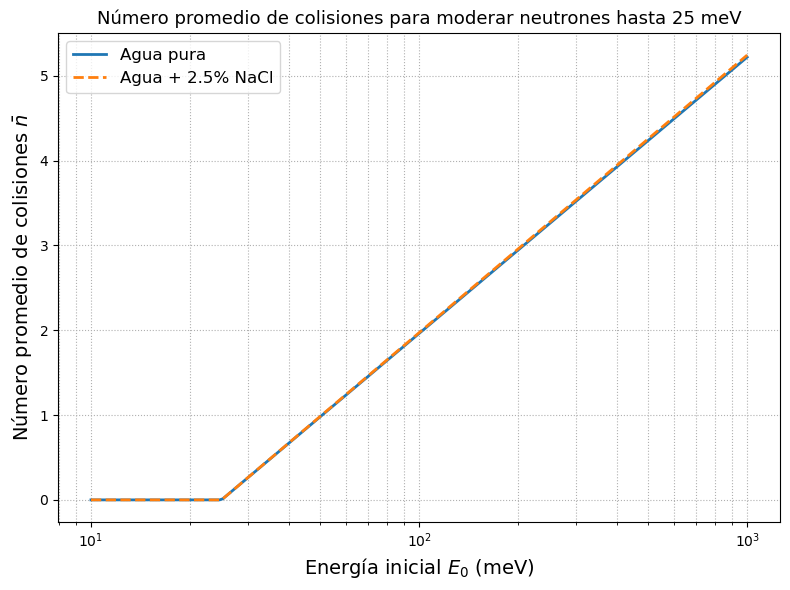

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Energías log-espaciadas en meV
E0 = np.logspace(np.log10(10), np.log10(1000), 200)

# Energía final
Ef = 25  # meV

# Parámetros xi
xi_agua = 0.70665
xi_salada = 0.70339

# Cálculo de número medio de colisiones (solo si E0 > Ef)
n_agua = np.where(E0 > Ef, np.log(E0 / Ef) / xi_agua, 0)
n_salada = np.where(E0 > Ef, np.log(E0 / Ef) / xi_salada, 0)

# Gráfica
plt.figure(figsize=(8,6))
plt.plot(E0, n_agua, label="Agua pura", linewidth=2)
plt.plot(E0, n_salada, label="Agua + 2.5% NaCl", linestyle="--", linewidth=2)

plt.xscale("log")
plt.xlabel("Energía inicial $E_0$ (meV)", fontsize=14)
plt.ylabel("Número promedio de colisiones $\\bar{n}$", fontsize=14)
plt.title("Número promedio de colisiones para moderar neutrones hasta 25 meV", fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls=":")
plt.tight_layout()
plt.show()


,Medio,Sigma_s (m^-1),Sigma_a (m^-1),p_abs por colisión (adim.)
0,Agua pura (1 m^3),215.630413,2.220286,0.010192
1,Agua + 2.5% NaCl (vol≈1.0071 m^3),214.723931,3.073892,0.014114


,E0_meV,nbar_agua,nbar_sol,survival_agua,survival_sol
199,1000.000000,5.220236,5.244430,0.947928,0.928166
0,10.000000,0.000000,0.000000,1.000000,1.000000
50,31.806257,0.340745,0.342324,0.996515,0.995146
100,101.163798,1.978158,1.987326,0.979940,0.972147
150,321.764175,3.615571,3.632328,0.963639,0.949680


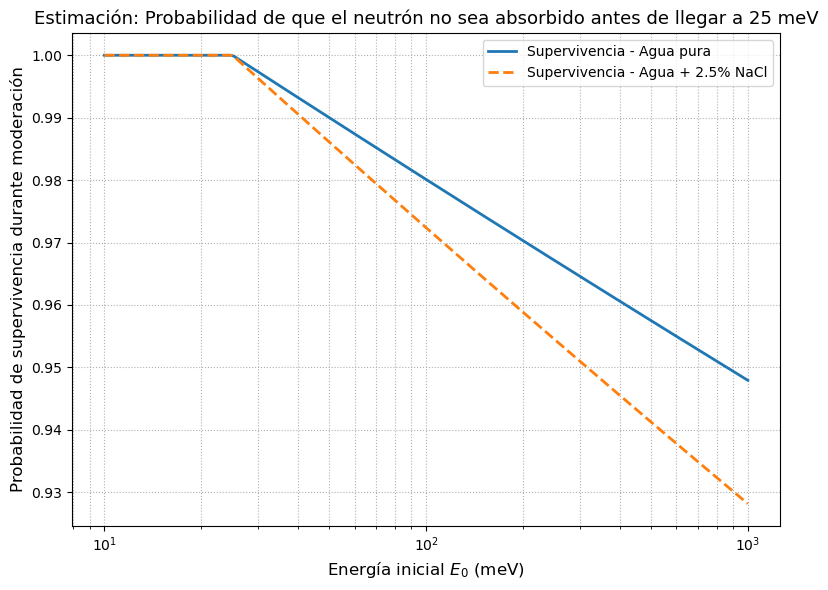

In [6]:
# Estimación de absorción durante la moderación (visible para el usuario)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constantes
NA = 6.02214076e23  # 1/mol
barn = 1e-28  # m^2
volume = 1.00710  # m^3 (volumen estimado para la solución 1 m^3 agua + 25 kg NaCl, de la estimación previa)
Ef = 25.0  # meV

# Masas (kg)
m_agua = 1000.0
m_NaCl = 25.0
m_total = m_agua + m_NaCl

# Moles y átomos
M_H2O = 0.018015  # kg/mol
M_NaCl = 0.05844  # kg/mol

n_H2O = m_agua / M_H2O
n_NaCl = m_NaCl / M_NaCl

# Átomos totales en el volumen (para la solución)
N_H = 2 * n_H2O * NA
N_O = 1 * n_H2O * NA
N_Na = n_NaCl * NA
N_Cl = n_NaCl * NA

# Número densidad (átomos por m^3)
nd_H = N_H / volume
nd_O = N_O / volume
nd_Na = N_Na / volume
nd_Cl = N_Cl / volume

# Cross sections (thermal, 0.0253 eV) - valores tomados de las tablas JENDL/JAEA y literatura
# Las unidades aquí están en barns; se convertirán a m^2 multiplicando por barn.
sigma_s_H_b = 30.27   # elastic scattering (H)
sigma_a_H_b = 0.332   # capture (H)

sigma_s_O_b = 3.965   # elastic scattering (O)
sigma_a_O_b = 0.0001899  # capture (O) ~ 189.9 microbarns

sigma_s_Na_b = 3.091  # elastic scattering (Na)
sigma_a_Na_b = 0.5314 # capture (Na) ~ 531.4 mb (JENDL Maxwellian average)

# Para Cl uso un valor representativo de captura de la literatura para Cl natural (~33.45 b)
# y scattering elástico tomado de la tabla JENDL para 35Cl (≈20.9 b) como aproximación para natural
sigma_s_Cl_b = 20.90
sigma_a_Cl_b = 33.45

# Convertir a m^2
sigma_s_H = sigma_s_H_b * barn
sigma_a_H = sigma_a_H_b * barn
sigma_s_O = sigma_s_O_b * barn
sigma_a_O = sigma_a_O_b * barn
sigma_s_Na = sigma_s_Na_b * barn
sigma_a_Na = sigma_a_Na_b * barn
sigma_s_Cl = sigma_s_Cl_b * barn
sigma_a_Cl = sigma_a_Cl_b * barn

# --- Caso 1: agua pura (solo H y O) ---
# Número de átomos en 1 m^3 de agua pura (asumimos volumen = 1.0 m^3)
vol_agua = 1.0
n_H2O_pura = m_agua / M_H2O
N_H_pura = 2 * n_H2O_pura * NA
N_O_pura = 1 * n_H2O_pura * NA
nd_H_pura = N_H_pura / vol_agua
nd_O_pura = N_O_pura / vol_agua

# Macroscópicas (m^-1)
Sigma_s_agua = nd_H_pura * sigma_s_H + nd_O_pura * sigma_s_O
Sigma_a_agua = nd_H_pura * sigma_a_H + nd_O_pura * sigma_a_O
p_abs_agua = Sigma_a_agua / (Sigma_a_agua + Sigma_s_agua)

# --- Caso 2: agua + 2.5% NaCl (usamos volume estimado de 1.00710 m^3) ---
Sigma_s_sol = nd_H * sigma_s_H + nd_O * sigma_s_O + nd_Na * sigma_s_Na + nd_Cl * sigma_s_Cl
Sigma_a_sol = nd_H * sigma_a_H + nd_O * sigma_a_O + nd_Na * sigma_a_Na + nd_Cl * sigma_a_Cl
p_abs_sol = Sigma_a_sol / (Sigma_a_sol + Sigma_s_sol)

# Mostrar parámetros claves
summary = pd.DataFrame({
    "Medio": ["Agua pura (1 m^3)", "Agua + 2.5% NaCl (vol≈1.0071 m^3)"],
    "Sigma_s (m^-1)": [Sigma_s_agua, Sigma_s_sol],
    "Sigma_a (m^-1)": [Sigma_a_agua, Sigma_a_sol],
    "p_abs por colisión (adim.)": [p_abs_agua, p_abs_sol]
})

# Ahora calcular supervivencia aproximada como (1 - p_abs)^{nbar(E0)} usando nbar = ln(E0/Ef)/xi
xi_agua = 0.70665
xi_sol = 0.70339

E0 = np.logspace(np.log10(10), np.log10(1000), 200)  # meV
nbar_agua = np.where(E0 > Ef, np.log(E0 / Ef) / xi_agua, 0.0)
nbar_sol = np.where(E0 > Ef, np.log(E0 / Ef) / xi_sol, 0.0)

survival_agua = np.where(nbar_agua>0, (1 - p_abs_agua)**nbar_agua, 1.0)
survival_sol = np.where(nbar_sol>0, (1 - p_abs_sol)**nbar_sol, 1.0)

# Crear DataFrame de salida (algunas columnas redondeadas)
df_out = pd.DataFrame({
    "E0_meV": E0,
    "nbar_agua": nbar_agua,
    "nbar_sol": nbar_sol,
    "survival_agua": survival_agua,
    "survival_sol": survival_sol
})

# Mostrar resumen y algunos valores clave
display(summary.round(6))
display(df_out.iloc[[ -1, 0, 50, 100, 150 ]].round(6))  # mostrar extremos y algunos puntos intermedios

# Gráfica de supervivencia (probabilidad de no ser absorbido durante la moderación)
plt.figure(figsize=(8,6))
plt.plot(E0, survival_agua, label="Supervivencia - Agua pura", linewidth=2)
plt.plot(E0, survival_sol, label="Supervivencia - Agua + 2.5% NaCl", linestyle="--", linewidth=2)
plt.xscale('log')
plt.xlabel("Energía inicial $E_0$ (meV)", fontsize=12)
plt.ylabel("Probabilidad de supervivencia durante moderación", fontsize=12)
plt.title("Estimación: Probabilidad de que el neutrón no sea absorbido antes de llegar a 25 meV", fontsize=13)
plt.legend()
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()



Resumen de la simulación (10,000 neutrones):

                              Agua pura  Agua + 2.5% NaCl
N_total                    10000.000000      10000.000000
N_absorbed                    52.000000        974.000000
frac_absorbed                  0.005200          0.097400
N_reached                   9948.000000       9026.000000
frac_reached                   0.994800          0.902600
mean_collisions_all            4.067400          3.760600
median_collisions_all          4.000000          4.000000
std_collisions_all             2.840292          2.809677
mean_collisions_reached        4.077101          3.905828
median_collisions_reached      4.000000          4.000000
std_collisions_reached         2.841650          2.833709


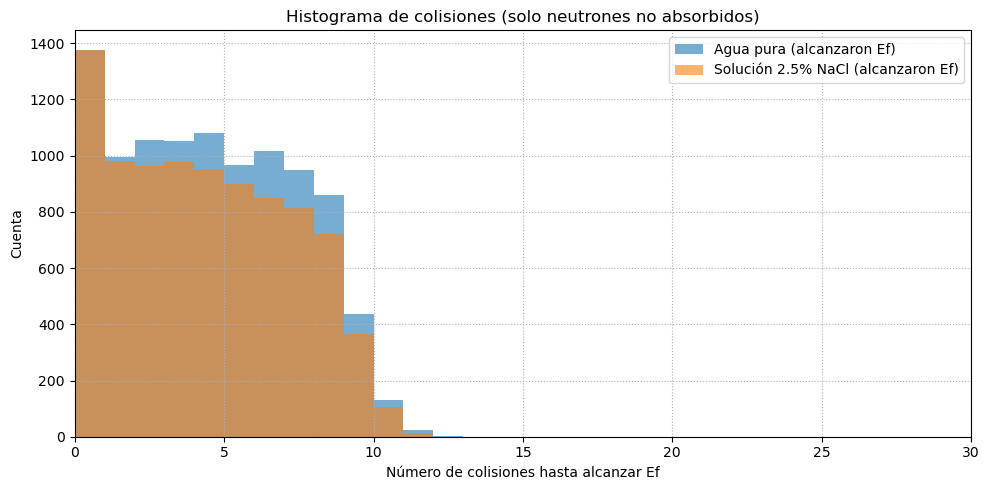

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Parámetros
N = 10000
E_min = 10.0      # meV
E_max = 10000.0   # meV
Ef = 25.0         # meV (energía objetivo)
max_collisions = 2000

# Medio: parámetros (ξ y p_abs por choque)
xi_agua = 0.70665
p_abs_agua = 0.001393

xi_sol = 0.70339
p_abs_sol = 0.0255

# Distribución inicial de energías: log-uniform en [E_min, E_max]
logE = np.random.uniform(np.log(E_min), np.log(E_max), size=N)
E0_all = np.exp(logE)

def simulate_medium(E0_array, xi, p_abs, Ef, max_collisions, sd_frac=0.3):
    N = len(E0_array)
    collisions = np.zeros(N, dtype=int)
    absorbed = np.zeros(N, dtype=bool)
    reached = np.zeros(N, dtype=bool)
    final_energy = np.copy(E0_array)
    
    for i in range(N):
        E = E0_array[i]
        if E <= Ef:
            reached[i] = True
            collisions[i] = 0
            continue
        c = 0
        while E > Ef and c < max_collisions:
            # Absorción por colisión
            if np.random.rand() < p_abs:
                absorbed[i] = True
                collisions[i] = c
                final_energy[i] = E
                break
            # Pérdida de energía
            u = -1.0
            while u <= 0:
                u = np.random.normal(loc=xi, scale=sd_frac*xi)
            E = E * np.exp(-u)
            c += 1
        if not absorbed[i]:
            collisions[i] = c
            final_energy[i] = E
            reached[i] = (E <= Ef)
    return collisions, absorbed, reached, final_energy

def summary_stats(collisions, absorbed, reached):
    survived = ~absorbed
    stats = {
        "N_total": len(collisions),
        "N_absorbed": int(absorbed.sum()),
        "frac_absorbed": float(absorbed.mean()),
        "N_reached": int(reached.sum()),
        "frac_reached": float(reached.mean()),
        "mean_collisions_all": float(collisions.mean()),
        "median_collisions_all": int(np.median(collisions)),
        "std_collisions_all": float(collisions.std()),
    }
    reached_mask = reached & (~absorbed)
    if reached_mask.sum() > 0:
        stats.update({
            "mean_collisions_reached": float(collisions[reached_mask].mean()),
            "median_collisions_reached": int(np.median(collisions[reached_mask])),
            "std_collisions_reached": float(collisions[reached_mask].std()),
        })
    else:
        stats.update({
            "mean_collisions_reached": np.nan,
            "median_collisions_reached": np.nan,
            "std_collisions_reached": np.nan,
        })
    return stats

# Simular
coll_agua, abs_agua, reach_agua, Efinal_agua = simulate_medium(E0_all, xi_agua, p_abs_agua, Ef, max_collisions)
coll_sol, abs_sol, reach_sol, Efinal_sol = simulate_medium(E0_all, xi_sol, p_abs_sol, Ef, max_collisions)

stats_agua = summary_stats(coll_agua, abs_agua, reach_agua)
stats_sol = summary_stats(coll_sol, abs_sol, reach_sol)

df_stats = pd.DataFrame([stats_agua, stats_sol], index=["Agua pura", "Agua + 2.5% NaCl"]).T
print("\nResumen de la simulación (10,000 neutrones):\n")
print(df_stats.round(6))

# Histogramas
plt.figure(figsize=(10,5))
plt.hist(coll_agua[~abs_agua], bins=range(0,31), alpha=0.6, label="Agua pura (alcanzaron Ef)")
plt.hist(coll_sol[~abs_sol], bins=range(0,31), alpha=0.6, label="Solución 2.5% NaCl (alcanzaron Ef)")
plt.xlim(0,30)
plt.xlabel("Número de colisiones hasta alcanzar Ef")
plt.ylabel("Cuenta")
plt.title("Histograma de colisiones (solo neutrones no absorbidos)")
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()


                      Medio  ξ efectivo  N° colisiones
0           Agua pura (H2O)    0.706667      14.995238
1  Agua con NaCl (H2O+NaCl)    0.642900      16.482555


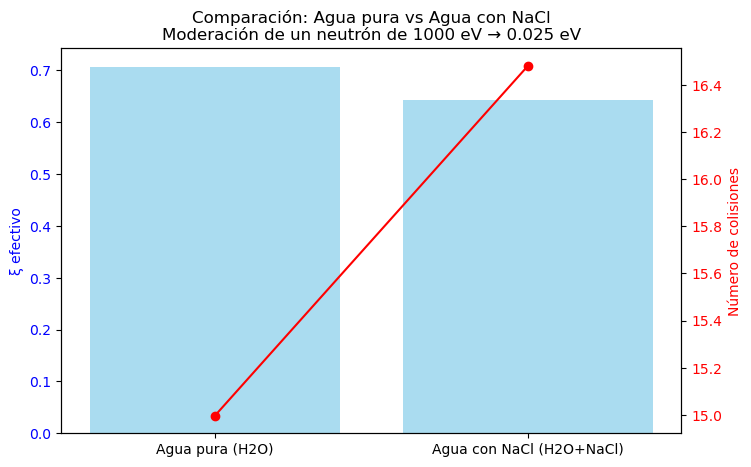

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Energías inicial y final
E0 = 1000.0   # eV
Ef = 0.025    # eV
ln_ratio = np.log(E0 / Ef)

# Reducción logarítmica media de la energía (xi) aproximada para cada núcleo
xi_values = {
    "H (A=1)": 1.0,
    "O (A=16)": 0.120,
    "Na (A=23)": 0.083,
    "Cl (A=35.5)": 0.055
}

# Composición (fracciones aproximadas de átomos moderadores)
# Para agua pura (H2O): 2H + 1O
fractions_H2O = {"H (A=1)": 2/3, "O (A=16)": 1/3}

# Para agua con NaCl (ejemplo: 1 H2O + 0.1 NaCl, muy simplificado)
fractions_H2O_NaCl = {"H (A=1)": 2/3 * 0.9, "O (A=16)": 1/3 * 0.9,
                      "Na (A=23)": 0.05, "Cl (A=35.5)": 0.05}

# Función para calcular ξ efectivo
def xi_effective(fractions, xi_values):
    xi_eff = 0
    for el, frac in fractions.items():
        xi_eff += frac * xi_values[el]
    return xi_eff

# Cálculo para agua pura
xi_H2O = xi_effective(fractions_H2O, xi_values)
n_H2O = ln_ratio / xi_H2O

# Cálculo para agua con NaCl
xi_H2O_NaCl = xi_effective(fractions_H2O_NaCl, xi_values)
n_H2O_NaCl = ln_ratio / xi_H2O_NaCl

# Crear tabla
data = {
    "Medio": ["Agua pura (H2O)", "Agua con NaCl (H2O+NaCl)"],
    "ξ efectivo": [xi_H2O, xi_H2O_NaCl],
    "N° colisiones": [n_H2O, n_H2O_NaCl]
}
df = pd.DataFrame(data)

# Mostrar tabla
print(df)

# Gráfica comparativa
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(df["Medio"], df["ξ efectivo"], color="skyblue", alpha=0.7, label="ξ efectivo")
ax1.set_ylabel("ξ efectivo", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(df["Medio"], df["N° colisiones"], marker="o", color="red", label="N° colisiones")
ax2.set_ylabel("Número de colisiones", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Comparación: Agua pura vs Agua con NaCl\nModeración de un neutrón de 1000 eV → 0.025 eV")
plt.show()


        Medio  ξ efectivo  N° colisiones
0    0 % NaCl    0.706667      14.995238
1  2.5 % NaCl    0.703324      15.066503
2    5 % NaCl    0.699843      15.141440
3   10 % NaCl    0.692431      15.303525


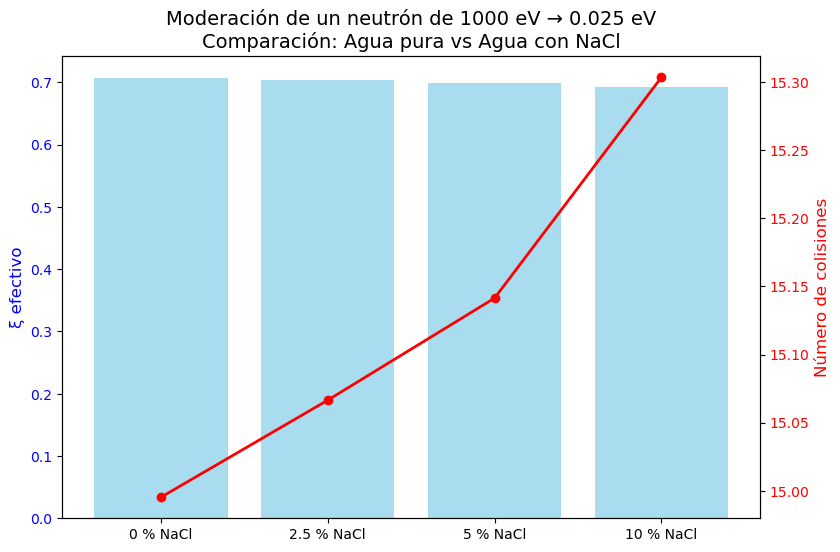

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Energías inicial y final
E0 = 1000.0   # eV
Ef = 0.025    # eV
ln_ratio = np.log(E0 / Ef)

# Reducción logarítmica media aproximada para cada núcleo
xi_values = {
    "H": 1.0,
    "O": 0.120,
    "Na": 0.083,
    "Cl": 0.055
}

# Masas molares (g/mol)
M_H2O = 18.015
M_NaCl = 58.44

def fracciones_atomicas(conc_NaCl_mass_percent):
    """
    Calcula fracciones atómicas de H, O, Na, Cl
    para una solución de NaCl en agua
    """
    # 100 g de solución
    m_NaCl = conc_NaCl_mass_percent
    m_H2O = 100 - m_NaCl
    
    # Moles
    mol_NaCl = m_NaCl / M_NaCl
    mol_H2O = m_H2O / M_H2O
    
    # Conteo de átomos
    N_H = 2 * mol_H2O
    N_O = 1 * mol_H2O
    N_Na = 1 * mol_NaCl
    N_Cl = 1 * mol_NaCl
    
    total = N_H + N_O + N_Na + N_Cl
    
    return {
        "H": N_H/total,
        "O": N_O/total,
        "Na": N_Na/total,
        "Cl": N_Cl/total
    }

def xi_effective(fractions):
    return sum(fractions[el] * xi_values[el] for el in fractions)

# Casos: Agua pura, 2.5%, 5%, 10% NaCl
concentraciones = [0, 2.5, 5, 10]
resultados = []

for c in concentraciones:
    fracs = fracciones_atomicas(c)
    xi_eff = xi_effective(fracs)
    n_coll = ln_ratio / xi_eff
    resultados.append([f"{c} % NaCl", xi_eff, n_coll])

# Tabla de resultados
df = pd.DataFrame(resultados, columns=["Medio", "ξ efectivo", "N° colisiones"])
print(df)

# Gráfica
fig, ax1 = plt.subplots(figsize=(9,6))

ax1.bar(df["Medio"], df["ξ efectivo"], color="skyblue", alpha=0.7, label="ξ efectivo")
ax1.set_ylabel("ξ efectivo", color="blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(df["Medio"], df["N° colisiones"], marker="o", color="red", linewidth=2, label="N° colisiones")
ax2.set_ylabel("Número de colisiones", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Moderación de un neutrón de 1000 eV → 0.025 eV\nComparación: Agua pura vs Agua con NaCl", fontsize=14)
plt.show()


# Histogramas agua pura

In [2]:
# Nombre del archivo de datos
archivo_datos = "numero-dispersiones-elasticas-AP-flujo-completo.txt"
# Lista para almacenar los datos
datos_n_AP_1meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_AP_1meV.append(valor)

In [3]:
# Nombre del archivo de datos
archivo_datos = "numero-dispersiones-elasticas-A-25NaCl-flujo-completo.txt"
# Lista para almacenar los datos
datos_n_AP_10meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_AP_10meV.append(valor)

In [4]:
# Nombre del archivo de datos
archivo_datos = "numero-dispersiones-elasticas-A-5NaCl-flujo-completo.txt"
# Lista para almacenar los datos
datos_n_AP_100meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_AP_100meV.append(valor)

In [5]:
# Nombre del archivo de datos
archivo_datos = "numero-dispersiones-elasticas-A-10NaCl-flujo-completo.txt"
# Lista para almacenar los datos
datos_n_AP_1000meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_AP_1000meV.append(valor)

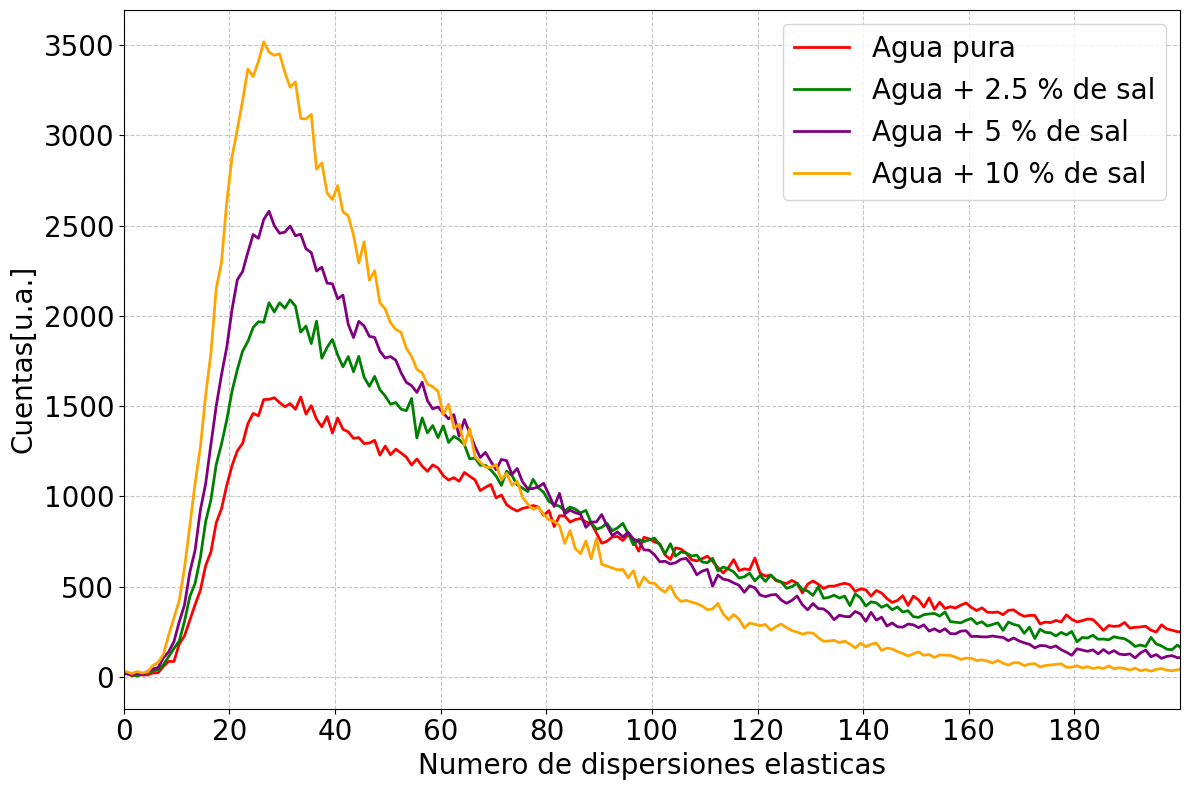

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 10000
inicio, fin = 0, 10000

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_AP_1meV, color='red', label='Agua pura')
plot_polygon(datos_n_AP_10meV, color='green', label='Agua + 2.5 % de sal')
plot_polygon(datos_n_AP_100meV, color='purple', label='Agua + 5 % de sal')
plot_polygon(datos_n_AP_1000meV, color='orange', label='Agua + 10 % de sal')


# Agregar etiquetas y formato
plt.xlabel('Numero de dispersiones elasticas', fontsize=20)
plt.ylabel('Cuentas[u.a.]', fontsize=20)
#plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 200)
plt.xticks(np.arange(0, 200, 20))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-temicos-Bga.jpg', format='jpg')
plt.savefig('numero-dispersion-elastica-neutron-temicos-Bga.pdf', format='pdf')
plt.show()


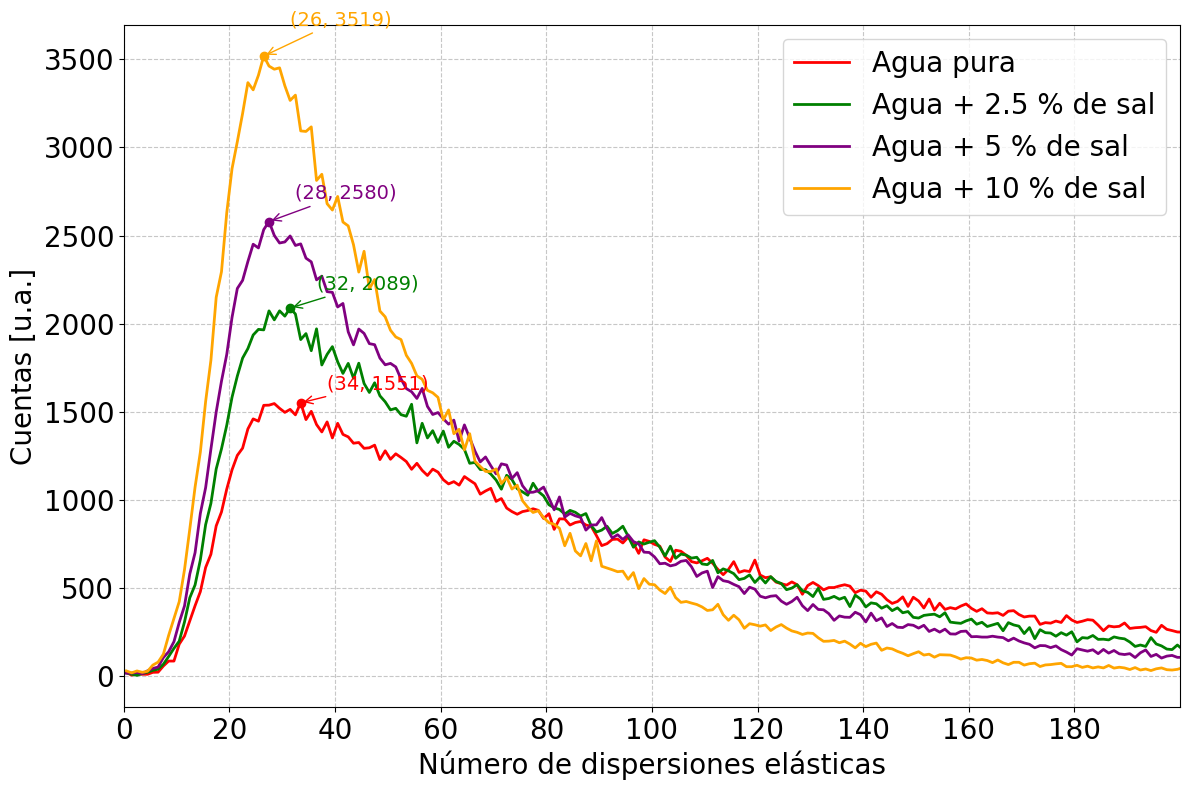

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 5000
inicio, fin = 0, 5000

# Función para calcular, graficar y marcar el máximo
def plot_polygon_with_max(data, color, label):
    # Histograma
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Graficar línea continua
    plt.plot(bin_centers, counts, linestyle='-', color=color,
             label=label, linewidth=2)

    # Determinar máximo
    idx_max = np.argmax(counts)
    x_max = bin_centers[idx_max]
    y_max = counts[idx_max]

    # Marcar máximo
    plt.plot(x_max, y_max, marker='o', color=color)

    # Anotar valor del máximo
    plt.annotate(
        f'({x_max:.0f}, {y_max:.0f})',
        xy=(x_max, y_max),
        xytext=(x_max + 5, y_max * 1.05),
        textcoords='data',
        fontsize=14,
        color=color,
        arrowprops=dict(arrowstyle='->', color=color)
    )

    return x_max, y_max

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar histogramas y obtener máximos
max_ap   = plot_polygon_with_max(datos_n_AP_1meV,    'red',    'Agua pura')
max_25   = plot_polygon_with_max(datos_n_AP_10meV,   'green',  'Agua + 2.5 % de sal')
max_5    = plot_polygon_with_max(datos_n_AP_100meV,  'purple', 'Agua + 5 % de sal')
max_10   = plot_polygon_with_max(datos_n_AP_1000meV, 'orange', 'Agua + 10 % de sal')

# Etiquetas y formato
plt.xlabel('Número de dispersiones elásticas', fontsize=20)
plt.ylabel('Cuentas [u.a.]', fontsize=20)

plt.xlim(0, 200)
plt.xticks(np.arange(0, 200, 20))

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tick_params(axis='both', which='major', labelsize=20)

plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-termicos-Bga-1.jpg', format='jpg')
plt.savefig('numero-dispersion-elastica-neutron-termicos-Bga-1.pdf', format='pdf')
plt.show()


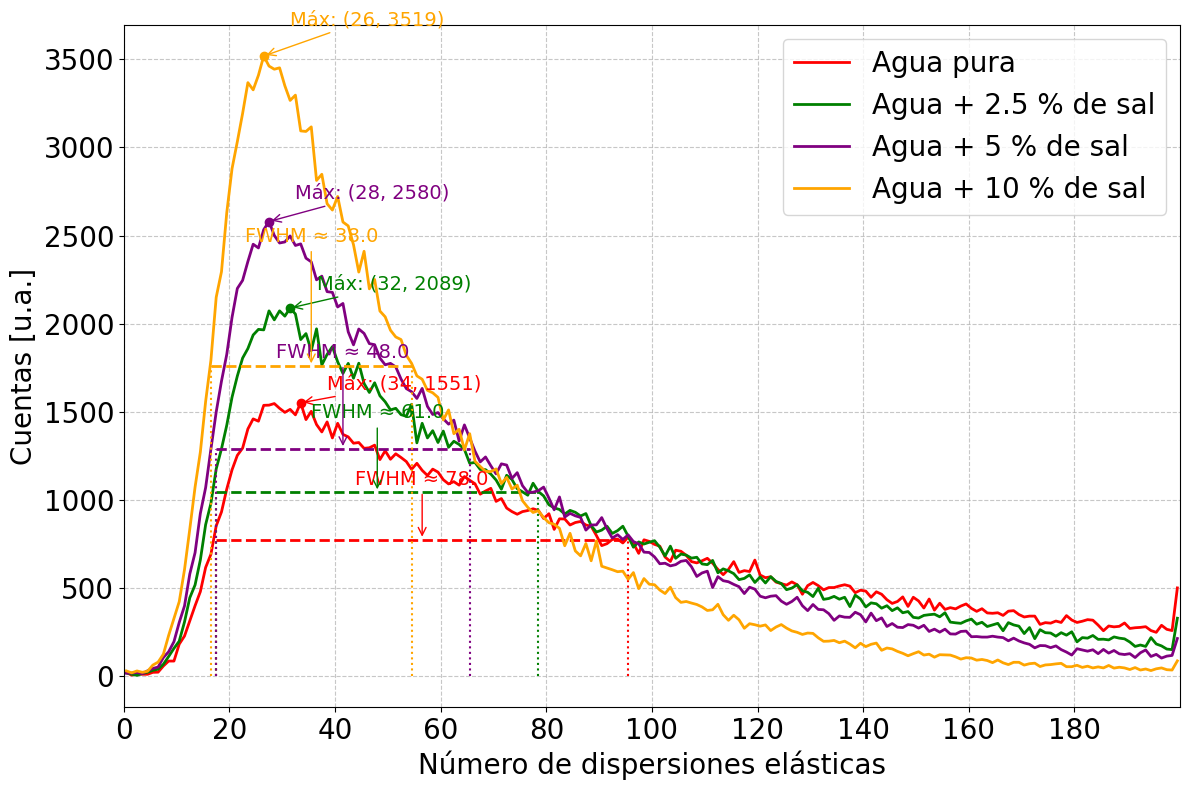

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

def plot_polygon_with_max_and_fwhm(data, color, label):
    # Histograma
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Graficar histograma como línea
    plt.plot(bin_centers, counts, linestyle='-', color=color,
             label=label, linewidth=2)

    # Máximo
    idx_max = np.argmax(counts)
    x_max = bin_centers[idx_max]
    y_max = counts[idx_max]

    # Nivel mitad del máximo
    half_max = y_max / 2

    # Índices donde el histograma cruza la mitad del máximo
    indices = np.where(counts >= half_max)[0]

    # Bordes FWHM
    left_idx = indices[0]
    right_idx = indices[-1]

    x_left = bin_centers[left_idx]
    x_right = bin_centers[right_idx]
    fwhm = x_right - x_left

    # Marcar máximo
    plt.plot(x_max, y_max, 'o', color=color)

    # Línea horizontal FWHM
    plt.hlines(half_max, x_left, x_right,
               colors=color, linestyles='dashed', linewidth=2)

    # Líneas verticales FWHM
    plt.vlines([x_left, x_right], 0, half_max,
               colors=color, linestyles='dotted', linewidth=1.5)

    # Anotaciones
    plt.annotate(
        f'Máx: ({x_max:.0f}, {y_max:.0f})',
        xy=(x_max, y_max),
        xytext=(x_max + 5, y_max * 1.05),
        fontsize=14,
        color=color,
        arrowprops=dict(arrowstyle='->', color=color)
    )

    plt.annotate(
        f'FWHM ≈ {fwhm:.1f}',
        xy=((x_left + x_right) / 2, half_max),
        xytext=((x_left + x_right) / 2, half_max * 1.4),
        fontsize=14,
        color=color,
        ha='center',
        arrowprops=dict(arrowstyle='->', color=color)
    )

    return x_max, y_max, fwhm

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar datos
plot_polygon_with_max_and_fwhm(datos_n_AP_1meV,    'red',    'Agua pura')
plot_polygon_with_max_and_fwhm(datos_n_AP_10meV,   'green',  'Agua + 2.5 % de sal')
plot_polygon_with_max_and_fwhm(datos_n_AP_100meV,  'purple', 'Agua + 5 % de sal')
plot_polygon_with_max_and_fwhm(datos_n_AP_1000meV, 'orange', 'Agua + 10 % de sal')

# Etiquetas y formato
plt.xlabel('Número de dispersiones elásticas', fontsize=20)
plt.ylabel('Cuentas [u.a.]', fontsize=20)

plt.xlim(0, 200)
plt.xticks(np.arange(0, 200, 20))

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tick_params(axis='both', which='major', labelsize=20)
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-termicos-FWHM-Bga.jpg')
plt.savefig('numero-dispersion-elastica-neutron-termicos-FWHM-Bga.pdf')
plt.show()


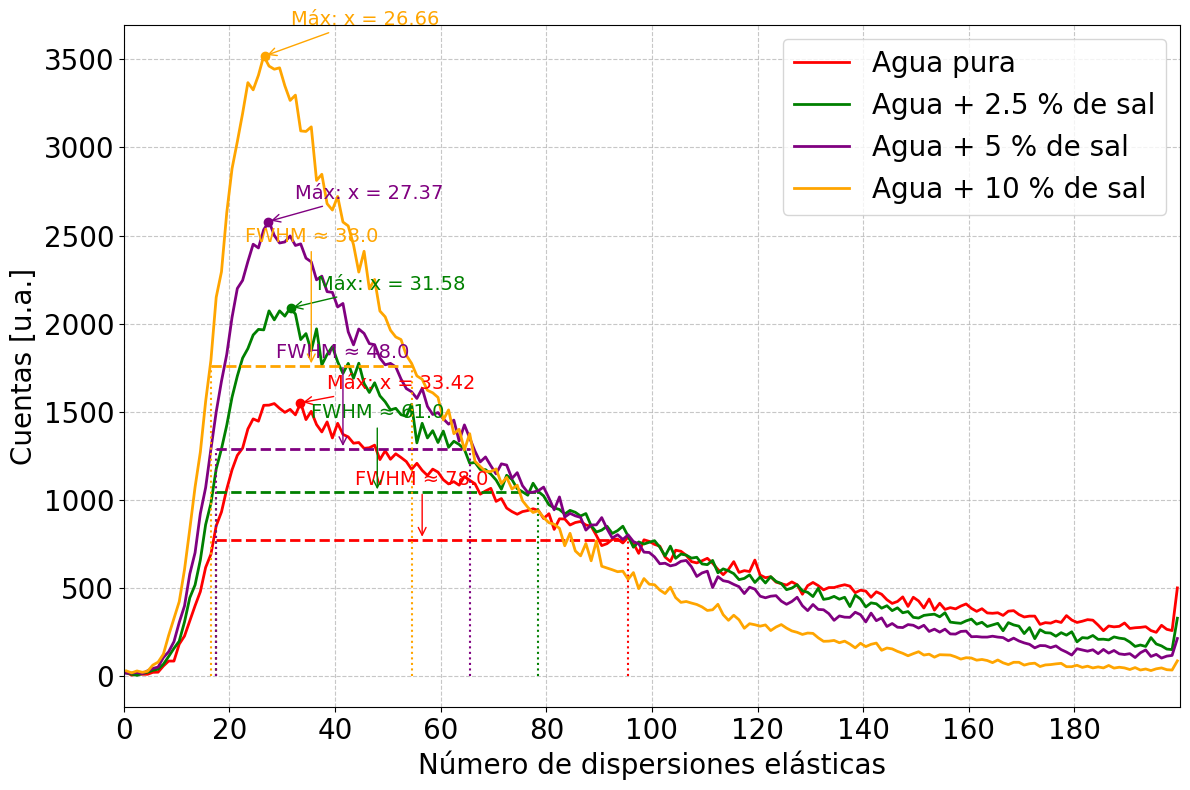

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# --- función auxiliar: máximo refinado ---
def refined_peak_position(bin_centers, counts):
    idx = np.argmax(counts)

    # Protección contra bordes
    if idx == 0 or idx == len(counts) - 1:
        return bin_centers[idx]

    # Tres puntos alrededor del máximo
    x = bin_centers[idx-1:idx+2]
    y = counts[idx-1:idx+2]

    # Ajuste parabólico local
    a, b, c = np.polyfit(x, y, 2)

    # Máximo analítico de la parábola
    x_peak = -b / (2 * a)

    return x_peak


def plot_polygon_with_max_and_fwhm(data, color, label):
    # Histograma
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Graficar histograma como línea
    plt.plot(bin_centers, counts, linestyle='-', color=color,
             label=label, linewidth=2)

    # Máximo discreto (bin)
    idx_max = np.argmax(counts)
    y_max = counts[idx_max]

    # Máximo refinado
    x_max_ref = refined_peak_position(bin_centers, counts)

    # Nivel mitad del máximo
    half_max = y_max / 2

    # Índices donde el histograma cruza la mitad del máximo
    indices = np.where(counts >= half_max)[0]
    left_idx = indices[0]
    right_idx = indices[-1]

    x_left = bin_centers[left_idx]
    x_right = bin_centers[right_idx]
    fwhm = x_right - x_left

    # Marcar máximo refinado
    plt.plot(x_max_ref, y_max, 'o', color=color)

    # Línea horizontal FWHM
    plt.hlines(half_max, x_left, x_right,
               colors=color, linestyles='dashed', linewidth=2)

    # Líneas verticales FWHM
    plt.vlines([x_left, x_right], 0, half_max,
               colors=color, linestyles='dotted', linewidth=1.5)

    # Anotaciones
    plt.annotate(
        f'Máx: x = {x_max_ref:.2f}',
        xy=(x_max_ref, y_max),
        xytext=(x_max_ref + 5, y_max * 1.05),
        fontsize=14,
        color=color,
        arrowprops=dict(arrowstyle='->', color=color)
    )

    plt.annotate(
        f'FWHM ≈ {fwhm:.1f}',
        xy=((x_left + x_right) / 2, half_max),
        xytext=((x_left + x_right) / 2, half_max * 1.4),
        fontsize=14,
        color=color,
        ha='center',
        arrowprops=dict(arrowstyle='->', color=color)
    )

    return x_max_ref, y_max, fwhm


# Crear figura
plt.figure(figsize=(12, 8))

# Graficar datos
plot_polygon_with_max_and_fwhm(datos_n_AP_1meV,    'red',    'Agua pura')
plot_polygon_with_max_and_fwhm(datos_n_AP_10meV,   'green',  'Agua + 2.5 % de sal')
plot_polygon_with_max_and_fwhm(datos_n_AP_100meV,  'purple', 'Agua + 5 % de sal')
plot_polygon_with_max_and_fwhm(datos_n_AP_1000meV, 'orange', 'Agua + 10 % de sal')

# Etiquetas y formato
plt.xlabel('Número de dispersiones elásticas', fontsize=20)
plt.ylabel('Cuentas [u.a.]', fontsize=20)

plt.xlim(0, 200)
plt.xticks(np.arange(0, 200, 20))

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tick_params(axis='both', which='major', labelsize=20)
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-termicos-FWHM-Bga.jpg')
plt.savefig('numero-dispersion-elastica-neutron-termicos-FWHM-Bga.pdf')
plt.show()


KeyError: (0, -1)

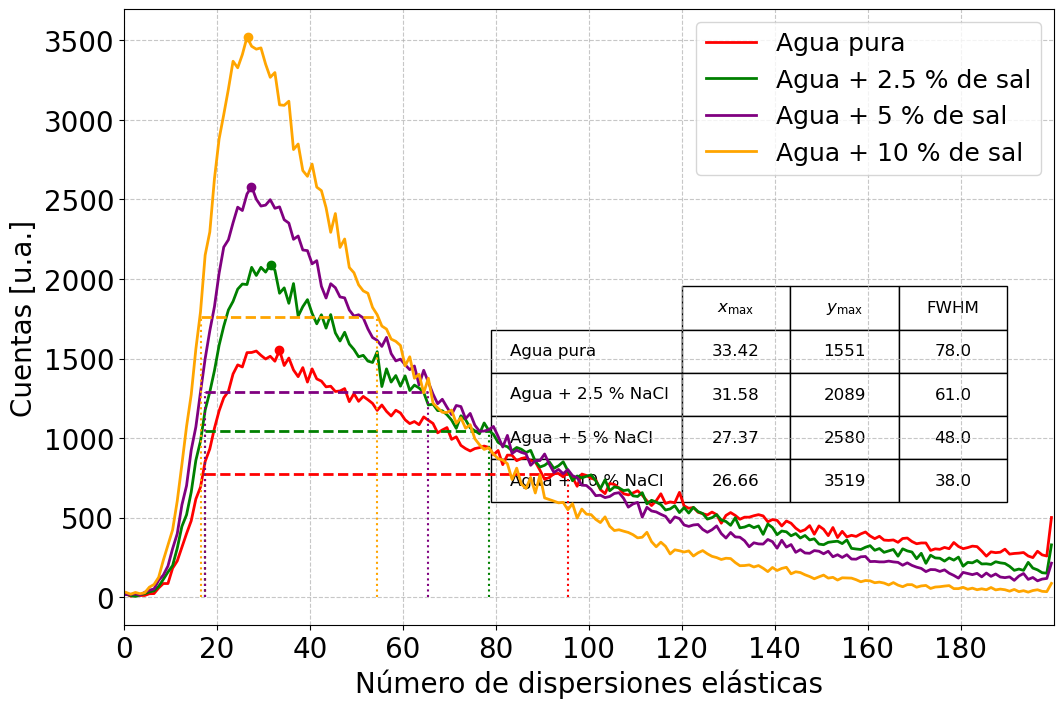

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# --- función auxiliar: máximo refinado ---
def refined_peak_position(bin_centers, counts):
    idx = np.argmax(counts)

    if idx == 0 or idx == len(counts) - 1:
        return bin_centers[idx]

    x = bin_centers[idx-1:idx+2]
    y = counts[idx-1:idx+2]

    a, b, c = np.polyfit(x, y, 2)
    x_peak = -b / (2 * a)

    return x_peak


def plot_polygon_with_max_and_fwhm(data, color, label):
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2

    plt.plot(bin_centers, counts, linestyle='-', color=color,
             label=label, linewidth=2)

    idx_max = np.argmax(counts)
    y_max = counts[idx_max]
    x_max_ref = refined_peak_position(bin_centers, counts)

    half_max = y_max / 2
    indices = np.where(counts >= half_max)[0]

    x_left = bin_centers[indices[0]]
    x_right = bin_centers[indices[-1]]
    fwhm = x_right - x_left

    # Marcar máximo refinado
    plt.plot(x_max_ref, y_max, 'o', color=color)

    # FWHM
    plt.hlines(half_max, x_left, x_right,
               colors=color, linestyles='dashed', linewidth=2)
    plt.vlines([x_left, x_right], 0, half_max,
               colors=color, linestyles='dotted', linewidth=1.5)

    return x_max_ref, y_max, fwhm


# Crear figura
fig, ax = plt.subplots(figsize=(12, 8))

# Almacenar resultados
resultados = []

resultados.append(
    ("Agua pura", *plot_polygon_with_max_and_fwhm(datos_n_AP_1meV, 'red', 'Agua pura'))
)
resultados.append(
    ("Agua + 2.5 % NaCl", *plot_polygon_with_max_and_fwhm(datos_n_AP_10meV, 'green', 'Agua + 2.5 % de sal'))
)
resultados.append(
    ("Agua + 5 % NaCl", *plot_polygon_with_max_and_fwhm(datos_n_AP_100meV, 'purple', 'Agua + 5 % de sal'))
)
resultados.append(
    ("Agua + 10 % NaCl", *plot_polygon_with_max_and_fwhm(datos_n_AP_1000meV, 'orange', 'Agua + 10 % de sal'))
)

# Formato de ejes
ax.set_xlabel('Número de dispersiones elásticas', fontsize=20)
ax.set_ylabel('Cuentas [u.a.]', fontsize=20)

ax.set_xlim(0, 200)
ax.set_xticks(np.arange(0, 200, 20))

ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.grid(axis="x", linestyle="--", alpha=0.7)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(fontsize=18)

# ---------- CUADRO RESUMEN ----------
table_data = [
    [f"{x:.2f}", f"{int(y)}", f"{w:.1f}"]
    for _, x, y, w in resultados
]

row_labels = [r[0] for r in resultados]
col_labels = [r"$x_{\max}$", r"$y_{\max}$", r"FWHM"]

tabla = plt.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    bbox=[0.60, 0.2, 0.35, 0.35],  # [x, y, width, height]
    colLoc='center',
    cellLoc='center'
)

tabla.scale(0.5, 1.4)
tabla.auto_set_font_size(False)
tabla.set_fontsize(12)

# Colores para los labels (primera columna)
label_colors = {
    0: 'red',      # Agua pura
    1: 'green',    # Agua + 2.5 % NaCl
    2: 'purple',   # Agua + 5 % NaCl
    3: 'orange'    # Agua + 10 % NaCl
}

# Acceder a las celdas de la tabla
cells = tabla.get_celld()

# Cambiar color SOLO a los rowLabels (columna -1)
for row, color in label_colors.items():
    cell = cells[(row, -1)]
    cell.set_text_props(color=color, weight='bold')


# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-termicos-FWHM-resumen-Bga.jpg')
plt.savefig('numero-dispersion-elastica-neutron-termicos-FWHM-resumen-Bga.pdf')
plt.show()


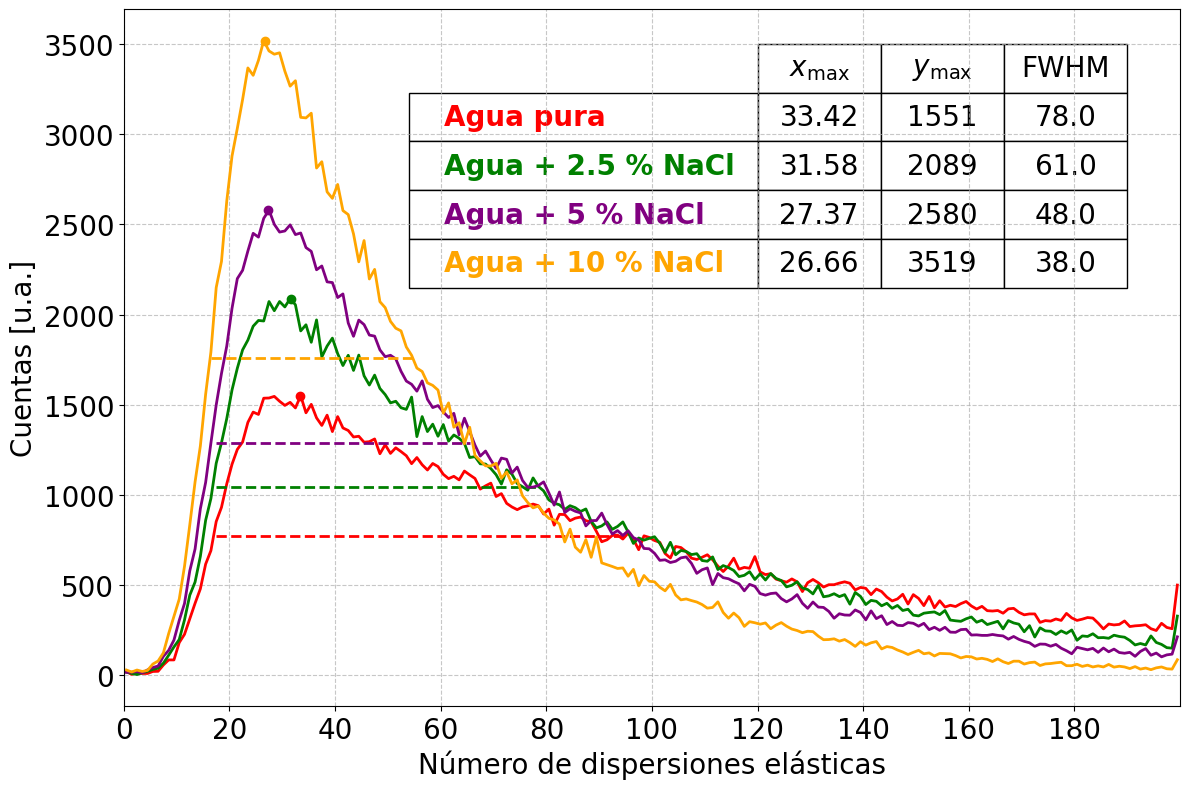

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# --- función auxiliar: máximo refinado ---
def refined_peak_position(bin_centers, counts):
    idx = np.argmax(counts)
    if idx == 0 or idx == len(counts) - 1:
        return bin_centers[idx]

    x = bin_centers[idx-1:idx+2]
    y = counts[idx-1:idx+2]
    a, b, c = np.polyfit(x, y, 2)

    return -b / (2 * a)


def plot_polygon_with_max_and_fwhm(data, color, label):
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Curva
    plt.plot(bin_centers, counts, color=color, linewidth=2, label=label)

    # Máximo refinado
    idx_max = np.argmax(counts)
    y_max = counts[idx_max]
    x_max = refined_peak_position(bin_centers, counts)

    # FWHM
    half_max = y_max / 2
    indices = np.where(counts >= half_max)[0]
    x_left = bin_centers[indices[0]]
    x_right = bin_centers[indices[-1]]
    fwhm = x_right - x_left

    # Marcadores
    plt.plot(x_max, y_max, 'o', color=color)
    plt.hlines(half_max, x_left, x_right, colors=color,
               linestyles='dashed', linewidth=2)

    return x_max, y_max, fwhm


# ================== FIGURA ==================
fig, ax = plt.subplots(figsize=(12, 8))

# Configuraciones físicas (color bien definido)
configuraciones = [
    ("Agua pura", datos_n_AP_1meV, "red"),
    ("Agua + 2.5 % NaCl", datos_n_AP_10meV, "green"),
    ("Agua + 5 % NaCl", datos_n_AP_100meV, "purple"),
    ("Agua + 10 % NaCl", datos_n_AP_1000meV, "orange"),
]

# Resultados
resultados = []

for nombre, datos, color in configuraciones:
    resultados.append(
        (nombre, *plot_polygon_with_max_and_fwhm(datos, color, nombre))
    )

# Formato de ejes
ax.set_xlabel('Número de dispersiones elásticas', fontsize=20)
ax.set_ylabel('Cuentas [u.a.]', fontsize=20)
ax.set_xlim(0, 200)
ax.set_xticks(np.arange(0, 200, 20))
ax.grid(True, linestyle="--", alpha=0.7)
ax.tick_params(axis='both', labelsize=20)

# Leyenda (solo las 4 curvas correctas)
#ax.legend(fontsize=18)

# ================== TABLA ==================
table_data = [
    [f"{x:.2f}", f"{int(y)}", f"{w:.1f}"]
    for _, x, y, w in resultados
]

row_labels = [r[0] for r in resultados]
col_labels = [r"$x_{\max}$", r"$y_{\max}$", r"FWHM"]

tabla = plt.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    bbox=[0.60, 0.6, 0.35, 0.35],
    colLoc='center',
    cellLoc='center'
)

tabla.scale(0.9, 1.4)
tabla.auto_set_font_size(False)
tabla.set_fontsize(20)
# Colores deseados para los rowLabels (en orden)
label_colors = ['red', 'green', 'purple', 'orange']

# Acceder a las celdas
cells = tabla.get_celld()

# Obtener filas de la columna -1 (rowLabels), ordenadas por fila
rowlabel_cells = sorted(
    [(row, cell) for (row, col), cell in cells.items() if col == -1],
    key=lambda x: x[0]
)

# Aplicar colores en orden
for (row, cell), color in zip(rowlabel_cells, label_colors):
    cell.set_text_props(color=color, weight='bold')


# Guardar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-termicos-FWHM-resumen-Bga.jpg')
plt.savefig('numero-dispersion-elastica-neutron-termicos-FWHM-resumen-Bga.pdf')
plt.show()


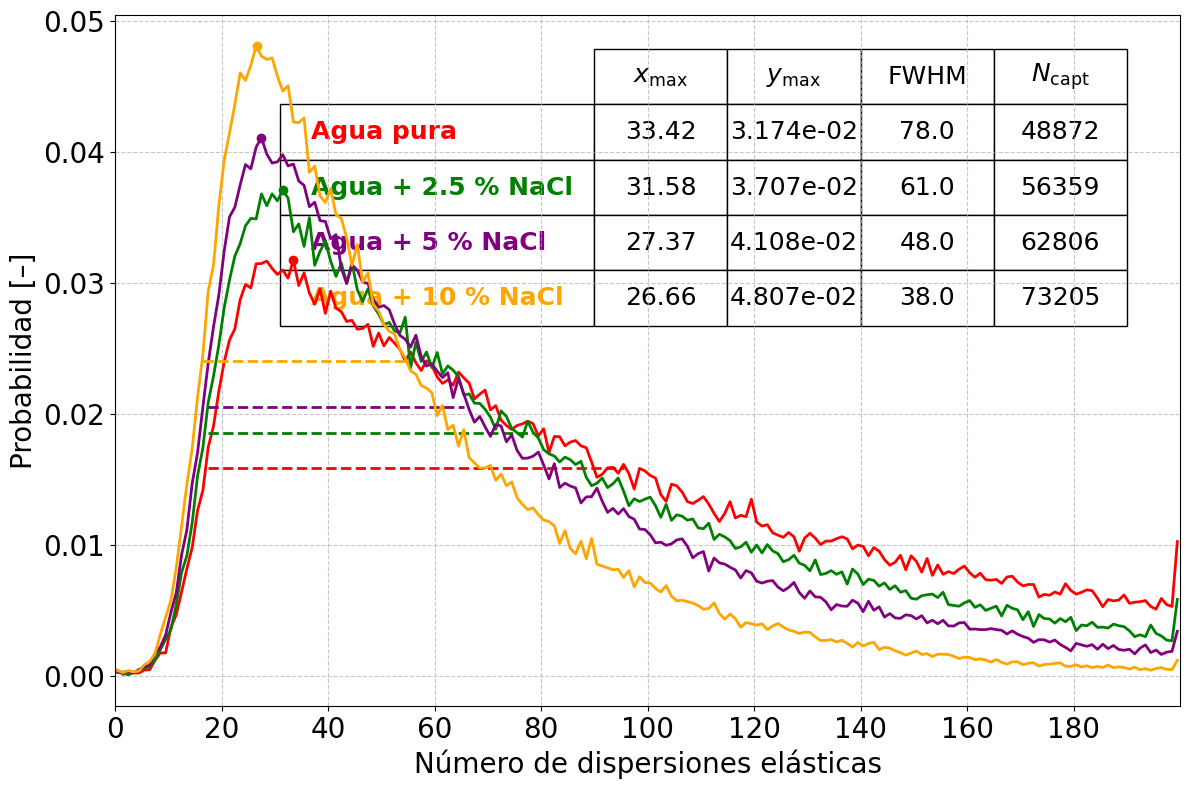

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# ================== CAPTURAS POR MEDIO ==================
capturas = {
    "Agua pura": 48872,
    "Agua + 2.5 % NaCl": 56359,
    "Agua + 5 % NaCl": 62806,
    "Agua + 10 % NaCl": 73205,
}

# --- función auxiliar: máximo refinado ---
def refined_peak_position(bin_centers, counts):
    idx = np.argmax(counts)
    if idx == 0 or idx == len(counts) - 1:
        return bin_centers[idx]

    x = bin_centers[idx-1:idx+2]
    y = counts[idx-1:idx+2]
    a, b, c = np.polyfit(x, y, 2)

    return -b / (2 * a)


def plot_polygon_with_max_and_fwhm(data, color, label, n_capt):
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # ================== NORMALIZACIÓN ==================
    counts_norm = counts / n_capt

    # Curva normalizada
    plt.plot(bin_centers, counts_norm, color=color, linewidth=2, label=label)

    # Máximo refinado (sobre histograma normalizado)
    idx_max = np.argmax(counts_norm)
    y_max = counts_norm[idx_max]
    x_max = refined_peak_position(bin_centers, counts_norm)

    # FWHM (definido sobre y_max normalizado)
    half_max = y_max / 2
    indices = np.where(counts_norm >= half_max)[0]
    x_left = bin_centers[indices[0]]
    x_right = bin_centers[indices[-1]]
    fwhm = x_right - x_left

    # Marcadores
    plt.plot(x_max, y_max, 'o', color=color)
    plt.hlines(half_max, x_left, x_right,
               colors=color, linestyles='dashed', linewidth=2)

    return x_max, y_max, fwhm, n_capt


# ================== FIGURA ==================
fig, ax = plt.subplots(figsize=(12, 8))

# Configuraciones físicas
configuraciones = [
    ("Agua pura", datos_n_AP_1meV, "red"),
    ("Agua + 2.5 % NaCl", datos_n_AP_10meV, "green"),
    ("Agua + 5 % NaCl", datos_n_AP_100meV, "purple"),
    ("Agua + 10 % NaCl", datos_n_AP_1000meV, "orange"),
]

# Resultados
resultados = []

for nombre, datos, color in configuraciones:
    resultados.append(
        (nombre, *plot_polygon_with_max_and_fwhm(
            datos, color, nombre, capturas[nombre]
        ))
    )

# ================== FORMATO ==================
ax.set_xlabel('Número de dispersiones elásticas', fontsize=20)
ax.set_ylabel('Probabilidad [–]', fontsize=20)
ax.set_xlim(0, 200)
ax.set_xticks(np.arange(0, 200, 20))
ax.grid(True, linestyle="--", alpha=0.7)
ax.tick_params(axis='both', labelsize=20)

# ================== TABLA ==================
table_data = [
    [f"{x:.2f}", f"{y:.3e}", f"{w:.1f}", f"{n}"]
    for _, x, y, w, n in resultados
]

row_labels = [r[0] for r in resultados]
col_labels = [r"$x_{\max}$", r"$y_{\max}$", r"FWHM", r"$N_{\mathrm{capt}}$"]

tabla = plt.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    bbox=[0.45, 0.55, 0.50, 0.40],
    colLoc='center',
    cellLoc='center'
)

tabla.scale(0.9, 1.4)
tabla.auto_set_font_size(False)
tabla.set_fontsize(18)

# Colorear rowLabels
label_colors = ['red', 'green', 'purple', 'orange']
cells = tabla.get_celld()
rowlabel_cells = sorted(
    [(row, cell) for (row, col), cell in cells.items() if col == -1],
    key=lambda x: x[0]
)
for (row, cell), color in zip(rowlabel_cells, label_colors):
    cell.set_text_props(color=color, weight='bold')

# ================== GUARDAR ==================
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-termicos-NORMALIZADO-Bga.jpg')
plt.savefig('numero-dispersion-elastica-neutron-termicos-NORMALIZADO-Bga.pdf')
plt.show()


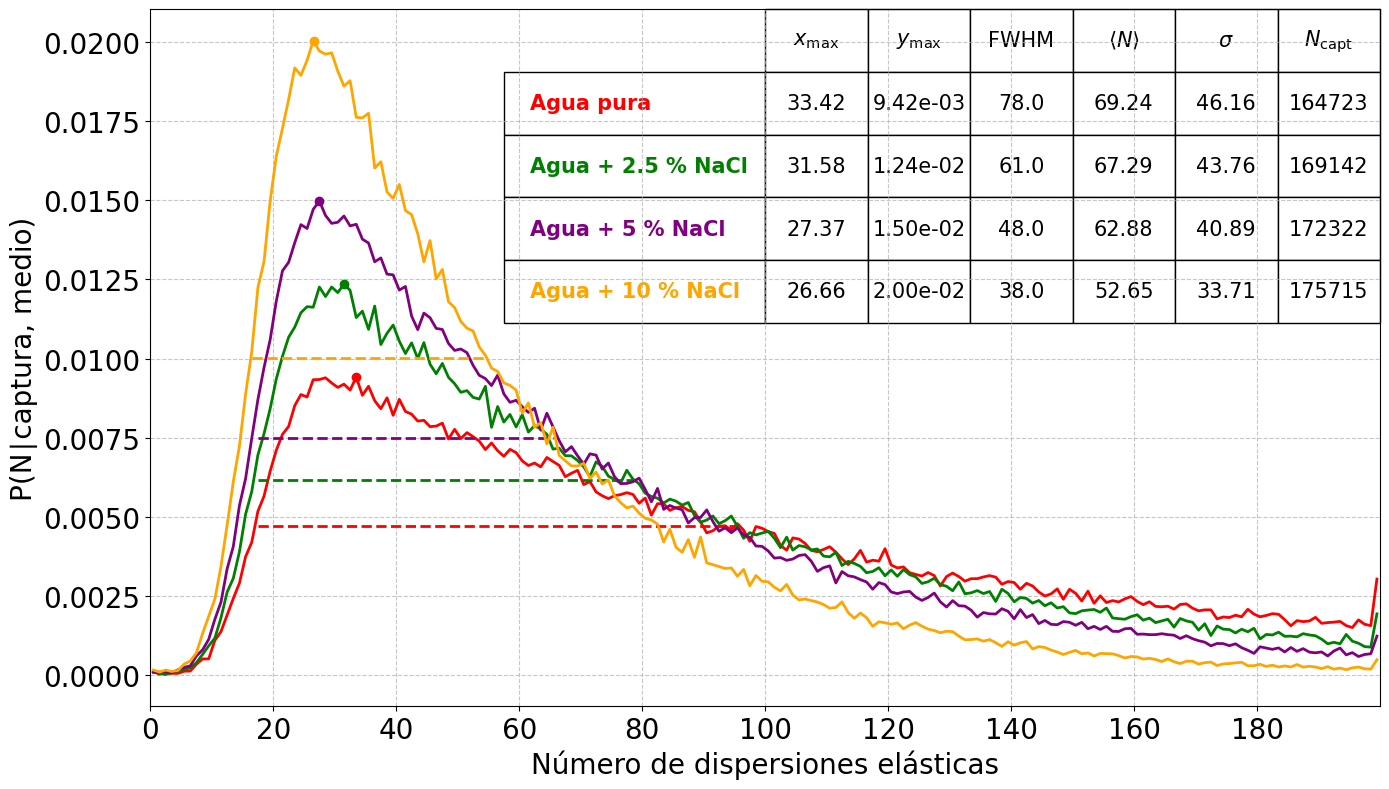

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# ================== CAPTURAS POR MEDIO ==================
capturas = {
    "Agua pura": 164723,
    "Agua + 2.5 % NaCl": 169142,
    "Agua + 5 % NaCl": 172322,
    "Agua + 10 % NaCl": 175715,
}

# --- función auxiliar: máximo refinado ---
def refined_peak_position(bin_centers, counts):
    idx = np.argmax(counts)
    if idx == 0 or idx == len(counts) - 1:
        return bin_centers[idx]

    x = bin_centers[idx-1:idx+2]
    y = counts[idx-1:idx+2]
    a, b, c = np.polyfit(x, y, 2)

    return -b / (2 * a)


def plot_polygon_with_max_and_fwhm(data, color, label, n_capt):
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # ================== NORMALIZACIÓN ==================
    counts_norm = counts / n_capt

    # Curva normalizada
    plt.plot(bin_centers, counts_norm, color=color, linewidth=2, label=label)

    # ================== ESTADÍSTICA ==================
    # Valor esperado <N>
    N_mean = np.sum(bin_centers * counts_norm)

    # Desviación estándar σ
    sigma = np.sqrt(np.sum((bin_centers - N_mean)**2 * counts_norm))

    # ================== MÁXIMO REFINADO ==================
    idx_max = np.argmax(counts_norm)
    y_max = counts_norm[idx_max]
    x_max = refined_peak_position(bin_centers, counts_norm)

    # ================== FWHM ==================
    half_max = y_max / 2
    indices = np.where(counts_norm >= half_max)[0]
    x_left = bin_centers[indices[0]]
    x_right = bin_centers[indices[-1]]
    fwhm = x_right - x_left

    # Marcadores
    plt.plot(x_max, y_max, 'o', color=color)
    plt.hlines(half_max, x_left, x_right,
               colors=color, linestyles='dashed', linewidth=2)

    return x_max, y_max, fwhm, N_mean, sigma, n_capt


# ================== FIGURA ==================
fig, ax = plt.subplots(figsize=(14, 8))

# Configuraciones físicas
configuraciones = [
    ("Agua pura", datos_n_AP_1meV, "red"),
    ("Agua + 2.5 % NaCl", datos_n_AP_10meV, "green"),
    ("Agua + 5 % NaCl", datos_n_AP_100meV, "purple"),
    ("Agua + 10 % NaCl", datos_n_AP_1000meV, "orange"),
]

# Resultados
resultados = []

for nombre, datos, color in configuraciones:
    resultados.append(
        (nombre, *plot_polygon_with_max_and_fwhm(
            datos, color, nombre, capturas[nombre]
        ))
    )

# ================== FORMATO ==================
ax.set_xlabel('Número de dispersiones elásticas', fontsize=20)
ax.set_ylabel('P(N∣captura, medio)', fontsize=20)
ax.set_xlim(0, 200)
ax.set_xticks(np.arange(0, 200, 20))
ax.grid(True, linestyle="--", alpha=0.7)
ax.tick_params(axis='both', labelsize=20)

# ================== TABLA ==================
table_data = [
    [f"{x:.2f}", f"{y:.2e}", f"{w:.1f}", f"{Nmean:.2f}", f"{sig:.2f}", f"{n}"]
    for _, x, y, w, Nmean, sig, n in resultados
]

row_labels = [r[0] for r in resultados]
col_labels = [
    r"$x_{\max}$",
    r"$y_{\max}$",
    r"FWHM",
    r"$\langle N \rangle$",
    r"$\sigma$",
    r"$N_{\mathrm{capt}}$"
]

tabla = plt.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    bbox=[0.50, 0.55, 0.50, 0.45],
    colLoc='center',
    cellLoc='center'
)

tabla.scale(0.5, 1.4)
tabla.auto_set_font_size(False)
tabla.set_fontsize(15)

# Colorear rowLabels
label_colors = ['red', 'green', 'purple', 'orange']
cells = tabla.get_celld()
rowlabel_cells = sorted(
    [(row, cell) for (row, col), cell in cells.items() if col == -1],
    key=lambda x: x[0]
)
for (row, cell), color in zip(rowlabel_cells, label_colors):
    cell.set_text_props(color=color, weight='bold')

# ================== GUARDAR ==================
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-flujo-completo-NORMALIZADO-Bga.jpg')
plt.savefig('numero-dispersion-elastica-flujo-completo-NORMALIZADO-Bga.pdf')
plt.show()


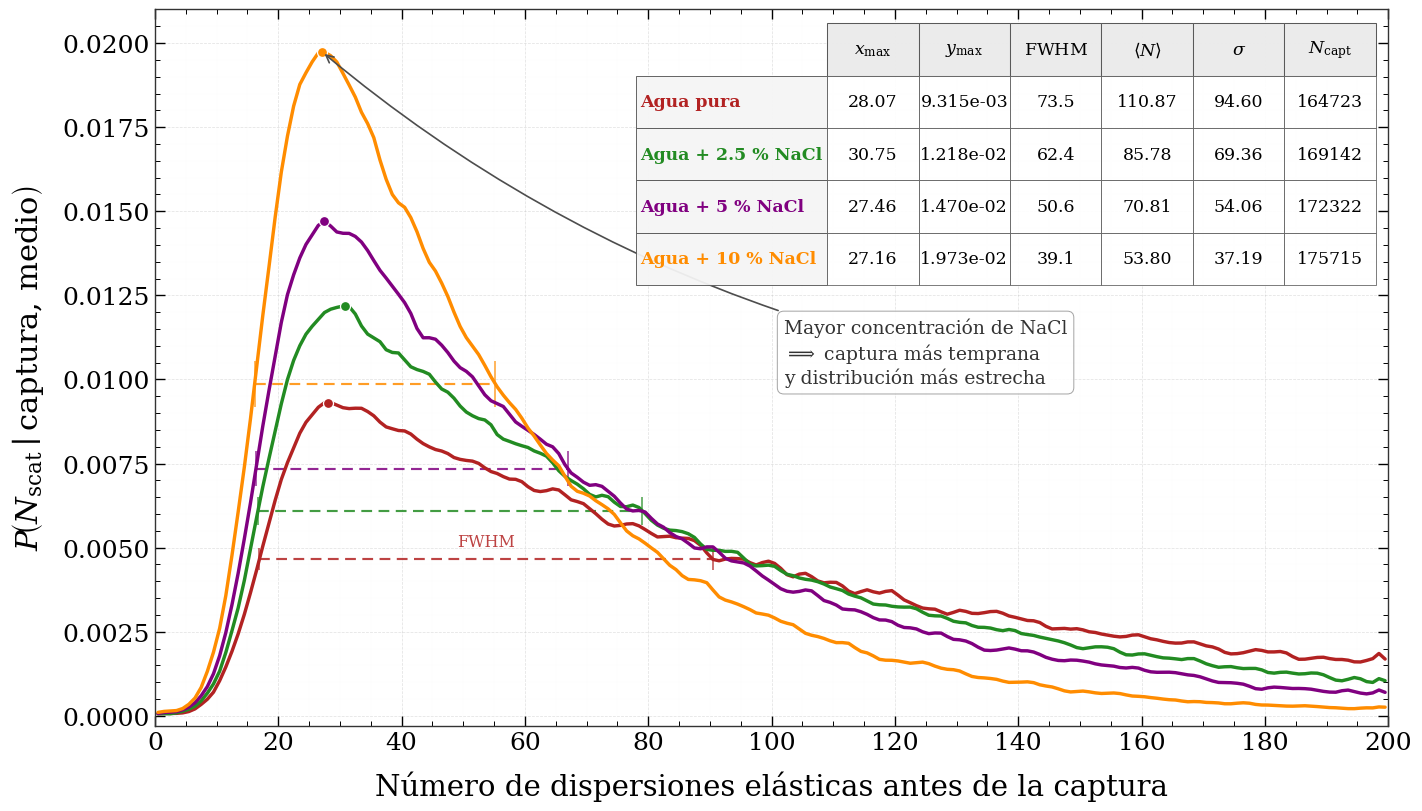


Figura generada correctamente.
JPG: numero-dispersion-elastica-flujo-completo-NORMALIZADO-Bga.jpg
PDF: numero-dispersion-elastica-flujo-completo-NORMALIZADO-Bga.pdf
Resultados: numero-dispersion-elastica-flujo-completo-NORMALIZADO-Bga-resultados.txt

Resumen de resultados
---------------------

Agua pura
  x_max       = 28.0677
  y_max       = 9.315274e-03
  FWHM        = 73.5116
  <N>         = 110.8679
  sigma       = 94.5994
  N_capt      = 164,723
  límite izq. = 16.9499
  límite der. = 90.4615

Agua + 2.5 % NaCl
  x_max       = 30.7473
  y_max       = 1.218162e-02
  FWHM        = 62.3587
  <N>         = 85.7817
  sigma       = 69.3634
  N_capt      = 169,142
  límite izq. = 16.7079
  límite der. = 79.0667

Agua + 5 % NaCl
  x_max       = 27.4636
  y_max       = 1.470469e-02
  FWHM        = 50.5692
  <N>         = 70.8086
  sigma       = 54.0584
  N_capt      = 172,322
  límite izq. = 16.3945
  límite der. = 66.9637

Agua + 10 % NaCl
  x_max       = 27.1606
  y_max       = 1.97305

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

NUMERO_BINS = 200

INICIO = 0
FIN = 200

ARCHIVO_SALIDA = (
    "numero-dispersion-elastica-flujo-completo-"
    "NORMALIZADO-Bga"
)

# Suavizado visual ligero.
#
# El suavizado se utiliza para mostrar mejor la tendencia,
# pero los estadísticos se calculan con los datos originales.
APLICAR_SUAVIZADO = True

# Desviación estándar del núcleo gaussiano, en número de bins.
SIGMA_SUAVIZADO = 1.0

# Mostrar anotación sobre la tendencia física.
MOSTRAR_TENDENCIA = True


# ==========================================================
# CAPTURAS POR MEDIO
# ==========================================================

capturas = {
    "Agua pura": 164723,
    "Agua + 2.5 % NaCl": 169142,
    "Agua + 5 % NaCl": 172322,
    "Agua + 10 % NaCl": 175715,
}


# ==========================================================
# COLORES
# ==========================================================

COLORES = {
    "Agua pura": "firebrick",
    "Agua + 2.5 % NaCl": "forestgreen",
    "Agua + 5 % NaCl": "purple",
    "Agua + 10 % NaCl": "darkorange",
}


# ==========================================================
# CONFIGURACIÓN TIPOGRÁFICA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "font.size": 16,
    "axes.labelsize": 21,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 14,

    "axes.linewidth": 1.0,

    # Mantener fuentes editables en PDF.
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# SUAVIZADO GAUSSIANO
# ==========================================================

def suavizado_gaussiano(valores, sigma=1.0):
    """
    Aplica un suavizado gaussiano unidimensional.

    No requiere scipy. El área de la distribución se conserva
    aproximadamente porque el núcleo se normaliza a la unidad.
    """

    valores = np.asarray(valores, dtype=float)

    if sigma <= 0:
        return valores.copy()

    radio = max(1, int(np.ceil(4.0 * sigma)))

    x_kernel = np.arange(
        -radio,
        radio + 1,
        dtype=float
    )

    kernel = np.exp(
        -0.5 * (x_kernel / sigma)**2
    )

    kernel /= np.sum(kernel)

    return np.convolve(
        valores,
        kernel,
        mode="same"
    )


# ==========================================================
# MÁXIMO REFINADO
# ==========================================================

def refined_peak_position(bin_centers, counts):
    """
    Refina la posición del máximo mediante un ajuste parabólico
    utilizando el bin máximo y sus dos bins vecinos.
    """

    idx = int(np.argmax(counts))

    if idx == 0 or idx == len(counts) - 1:
        return float(bin_centers[idx])

    x = bin_centers[idx - 1:idx + 2]
    y = counts[idx - 1:idx + 2]

    a, b, _ = np.polyfit(x, y, 2)

    if np.isclose(a, 0.0):
        return float(bin_centers[idx])

    x_refinado = -b / (2.0 * a)

    # Evitar que el ajuste parabólico genere una posición
    # fuera de los tres bins usados.
    return float(
        np.clip(
            x_refinado,
            x[0],
            x[-1]
        )
    )


# ==========================================================
# INTERPOLACIÓN DE CRUCES A MEDIA ALTURA
# ==========================================================

def interpolar_cruce(x1, y1, x2, y2, nivel):
    """
    Interpola linealmente la posición donde una curva cruza
    un nivel determinado.
    """

    if np.isclose(y2, y1):
        return 0.5 * (x1 + x2)

    return x1 + (
        (nivel - y1)
        * (x2 - x1)
        / (y2 - y1)
    )


# ==========================================================
# CÁLCULO DEL FWHM
# ==========================================================

def calcular_fwhm(x, y):
    """
    Calcula el ancho a media altura mediante interpolación
    lineal en los cruces izquierdo y derecho.
    """

    idx_max = int(np.argmax(y))
    y_max = float(y[idx_max])
    half_max = y_max / 2.0

    # ------------------------------------------------------
    # Cruce izquierdo
    # ------------------------------------------------------

    idx_izquierdo = None

    for i in range(idx_max, 0, -1):

        if y[i - 1] < half_max <= y[i]:
            idx_izquierdo = i
            break

    if idx_izquierdo is None:

        x_left = float(x[0])

    else:

        x_left = interpolar_cruce(
            x[idx_izquierdo - 1],
            y[idx_izquierdo - 1],
            x[idx_izquierdo],
            y[idx_izquierdo],
            half_max
        )

    # ------------------------------------------------------
    # Cruce derecho
    # ------------------------------------------------------

    idx_derecho = None

    for i in range(idx_max, len(y) - 1):

        if y[i] >= half_max > y[i + 1]:
            idx_derecho = i
            break

    if idx_derecho is None:

        x_right = float(x[-1])

    else:

        x_right = interpolar_cruce(
            x[idx_derecho],
            y[idx_derecho],
            x[idx_derecho + 1],
            y[idx_derecho + 1],
            half_max
        )

    fwhm = x_right - x_left

    return (
        float(x_left),
        float(x_right),
        float(fwhm),
        float(half_max)
    )


# ==========================================================
# FUNCIÓN DE GRAFICACIÓN Y ESTADÍSTICA
# ==========================================================

def plot_polygon_with_max_and_fwhm(
    ax,
    data,
    color,
    label,
    n_capt
):
    """
    Construye la distribución normalizada, calcula los
    estadísticos y dibuja máximo y FWHM.
    """

    data = np.asarray(data, dtype=float)

    data = data[
        np.isfinite(data)
    ]

    if data.size == 0:
        raise ValueError(
            f"No existen datos válidos para: {label}"
        )

    if n_capt <= 0:
        raise ValueError(
            f"Número de capturas no válido para: {label}"
        )

    # ======================================================
    # HISTOGRAMA
    # ======================================================

    counts, bins = np.histogram(
        data,
        bins=NUMERO_BINS,
        range=(INICIO, FIN)
    )

    bin_centers = 0.5 * (
        bins[:-1] + bins[1:]
    )

    # ======================================================
    # NORMALIZACIÓN
    # ======================================================
    #
    # P(N | captura, medio) = cuentas del bin / N_capt
    # ======================================================

    counts_norm = (
        counts.astype(float) / float(n_capt)
    )

    # Suavizado exclusivamente visual.
    if APLICAR_SUAVIZADO:

        curva_grafica = suavizado_gaussiano(
            counts_norm,
            sigma=SIGMA_SUAVIZADO
        )

    else:

        curva_grafica = counts_norm.copy()

    # ======================================================
    # ESTADÍSTICA DIRECTA DE LOS DATOS
    # ======================================================
    #
    # Se calculan media y desviación estándar directamente
    # con los eventos individuales, no con la curva suavizada.
    # ======================================================

    N_mean = float(np.mean(data))

    sigma = float(
        np.std(
            data,
            ddof=0
        )
    )

    # ======================================================
    # MÁXIMO REFINADO
    # ======================================================

    idx_max = int(
        np.argmax(curva_grafica)
    )

    y_max = float(
        curva_grafica[idx_max]
    )

    x_max = refined_peak_position(
        bin_centers,
        curva_grafica
    )

    # Para representar y_max en la posición refinada se usa
    # interpolación sobre la curva.
    y_max_refinado = float(
        np.interp(
            x_max,
            bin_centers,
            curva_grafica
        )
    )

    # ======================================================
    # FWHM
    # ======================================================

    x_left, x_right, fwhm, half_max = calcular_fwhm(
        bin_centers,
        curva_grafica
    )

    # ======================================================
    # CURVA PRINCIPAL
    # ======================================================

    ax.plot(
        bin_centers,
        curva_grafica,
        color=color,
        linewidth=2.45,
        label=label,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=4
    )

    # ======================================================
    # MARCADOR DEL MÁXIMO
    # ======================================================

    ax.plot(
        x_max,
        y_max_refinado,
        marker="o",
        markersize=7.2,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.9,
        linestyle="none",
        zorder=8
    )

    # ======================================================
    # LÍNEA DEL FWHM
    # ======================================================

    ax.hlines(
        y=half_max,
        xmin=x_left,
        xmax=x_right,
        colors=color,
        linestyles=(0, (5, 3)),
        linewidth=1.55,
        alpha=0.85,
        zorder=3
    )

    # Pequeñas marcas verticales en los extremos del FWHM.
    altura_marca = 0.035 * y_max

    ax.vlines(
        [x_left, x_right],
        ymin=half_max - altura_marca,
        ymax=half_max + altura_marca,
        colors=color,
        linewidth=1.2,
        alpha=0.75,
        zorder=3
    )

    return (
        x_max,
        y_max,
        fwhm,
        N_mean,
        sigma,
        n_capt,
        x_left,
        x_right,
        half_max
    )


# ==========================================================
# CONFIGURACIONES FÍSICAS
# ==========================================================

configuraciones = [
    (
        "Agua pura",
        datos_n_AP_1meV,
        COLORES["Agua pura"]
    ),
    (
        "Agua + 2.5 % NaCl",
        datos_n_AP_10meV,
        COLORES["Agua + 2.5 % NaCl"]
    ),
    (
        "Agua + 5 % NaCl",
        datos_n_AP_100meV,
        COLORES["Agua + 5 % NaCl"]
    ),
    (
        "Agua + 10 % NaCl",
        datos_n_AP_1000meV,
        COLORES["Agua + 10 % NaCl"]
    ),
]


# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, ax = plt.subplots(
    figsize=(14.5, 8.4)
)

resultados = []


# ==========================================================
# GRAFICAR LAS CONFIGURACIONES
# ==========================================================

for nombre, datos, color in configuraciones:

    resultado = plot_polygon_with_max_and_fwhm(
        ax=ax,
        data=datos,
        color=color,
        label=nombre,
        n_capt=capturas[nombre]
    )

    resultados.append(
        (
            nombre,
            *resultado
        )
    )


# ==========================================================
# FORMATO DE LOS EJES
# ==========================================================

ax.set_xlabel(
    "Número de dispersiones elásticas antes de la captura",
    fontsize=21,
    labelpad=12
)

ax.set_ylabel(
    r"$P\!\left("
    r"N_{\mathrm{scat}}"
    r"\mid"
    r"\mathrm{captura},\,"
    r"\mathrm{medio}"
    r"\right)$",
    fontsize=22,
    labelpad=12
)

ax.set_xlim(
    INICIO,
    FIN
)

ax.set_xticks(
    np.arange(
        INICIO,
        FIN + 1,
        20
    )
)

# Formato decimal uniforme del eje vertical.
ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.4f")
)

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=7,
    width=1.0,
    labelsize=18,
    top=True,
    right=True
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3.5,
    width=0.7,
    top=True,
    right=True
)

ax.minorticks_on()


# ==========================================================
# CUADRÍCULA
# ==========================================================

ax.grid(
    visible=True,
    which="major",
    linestyle="--",
    linewidth=0.55,
    alpha=0.35
)

ax.grid(
    visible=True,
    which="minor",
    linestyle=":",
    linewidth=0.30,
    alpha=0.10
)

ax.set_axisbelow(True)


# ==========================================================
# TABLA DE RESULTADOS
# ==========================================================

table_data = [
    [
        f"{x_max:.2f}",
        f"{y_max:.3e}",
        f"{fwhm:.1f}",
        f"{N_mean:.2f}",
        f"{sigma:.2f}",
        f"{n_capt:}"
    ]
    for (
        _,
        x_max,
        y_max,
        fwhm,
        N_mean,
        sigma,
        n_capt,
        _,
        _,
        _
    ) in resultados
]

row_labels = [
    resultado[0]
    for resultado in resultados
]

col_labels = [
    r"$x_{\max}$",
    r"$y_{\max}$",
    r"$\mathrm{FWHM}$",
    r"$\langle N\rangle$",
    r"$\sigma$",
    r"$N_{\mathrm{capt}}$"
]

tabla = ax.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,

    # Tabla más pequeña y desplazada hacia arriba-derecha.
    bbox=[
        0.545,
        0.615,
        0.445,
        0.365
    ],

    colLoc="center",
    cellLoc="center",

    zorder=20
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(12.5)


# ==========================================================
# FORMATO GENERAL DE LA TABLA
# ==========================================================

cells = tabla.get_celld()

for (row, column), cell in cells.items():

    cell.set_edgecolor("0.35")
    cell.set_linewidth(0.55)

    # Fondo blanco ligeramente transparente.
    cell.set_facecolor(
        (1.0, 1.0, 1.0, 0.92)
    )

    cell.PAD = 0.025


# ==========================================================
# FORMATO DEL ENCABEZADO
# ==========================================================

for column in range(
    len(col_labels)
):

    cell = cells[(0, column)]

    cell.set_facecolor(
        (0.92, 0.92, 0.92, 0.96)
    )

    cell.set_text_props(
        weight="bold",
        color="black",
        fontsize=12.5
    )

    cell.set_linewidth(0.75)


# ==========================================================
# ETIQUETAS DE LAS FILAS
# ==========================================================

for row_index, (
    nombre,
    _,
    color
) in enumerate(
    configuraciones,
    start=1
):

    row_label_cell = cells[
        (row_index, -1)
    ]

    row_label_cell.set_text_props(
        color=color,
        weight="bold",
        fontsize=12.5
    )

    row_label_cell.set_facecolor(
        (0.96, 0.96, 0.96, 0.94)
    )

    row_label_cell.set_linewidth(0.65)


# ==========================================================
# ANOTACIÓN DE LA TENDENCIA FÍSICA
# ==========================================================

if MOSTRAR_TENDENCIA:

    ax.annotate(
        (
            "Mayor concentración de NaCl\n"
            r"$\Longrightarrow$ captura más temprana"
            "\ny distribución más estrecha"
        ),

        xy=(
            resultados[-1][1],
            resultados[-1][2]
        ),

        xytext=(
            102,
            0.0108
        ),

        fontsize=13.5,
        ha="left",
        va="center",
        color="0.20",

        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.2,
            color="0.30",
            connectionstyle="arc3,rad=-0.12"
        ),

        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="0.60",
            linewidth=0.7,
            alpha=0.90
        ),

        zorder=15
    )


# ==========================================================
# INDICACIÓN DISCRETA DEL FWHM
# ==========================================================

# Se toma la primera distribución como ejemplo.
primer_resultado = resultados[0]

x_left_agua = primer_resultado[7]
x_right_agua = primer_resultado[8]
half_max_agua = primer_resultado[9]

ax.text(
    0.5 * (
        x_left_agua + x_right_agua
    ),
    half_max_agua * 1.06,
    "FWHM",
    color=COLORES["Agua pura"],
    fontsize=11.5,
    ha="center",
    va="bottom",
    alpha=0.85,
    zorder=7
)


# ==========================================================
# BORDES DE LA FIGURA
# ==========================================================

for spine in ax.spines.values():

    spine.set_linewidth(1.0)
    spine.set_color("0.20")


# ==========================================================
# AJUSTAR LÍMITE VERTICAL
# ==========================================================

# Se deja espacio suficiente para la tabla.
maximo_global = max(
    resultado[2]
    for resultado in resultados
)

ax.set_ylim(
    bottom=-0.0003,
    top=maximo_global * 1.065
)


# ==========================================================
# GUARDAR RESULTADOS NUMÉRICOS
# ==========================================================

archivo_resultados = (
    ARCHIVO_SALIDA
    + "-resultados.txt"
)

with open(
    archivo_resultados,
    "w",
    encoding="utf-8"
) as archivo:

    archivo.write(
        "# Resultados de las distribuciones normalizadas\n"
    )

    archivo.write(
        "# P(N | captura, medio)\n"
    )

    archivo.write(
        "#\n"
    )

    archivo.write(
        "# Medio\t"
        "x_max\t"
        "y_max\t"
        "FWHM\t"
        "N_mean\t"
        "sigma\t"
        "N_capt\t"
        "x_left_FWHM\t"
        "x_right_FWHM\n"
    )

    for (
        nombre,
        x_max,
        y_max,
        fwhm,
        N_mean,
        sigma,
        n_capt,
        x_left,
        x_right,
        _
    ) in resultados:

        archivo.write(
            f"{nombre}\t"
            f"{x_max:.8f}\t"
            f"{y_max:.10e}\t"
            f"{fwhm:.8f}\t"
            f"{N_mean:.8f}\t"
            f"{sigma:.8f}\t"
            f"{n_capt:d}\t"
            f"{x_left:.8f}\t"
            f"{x_right:.8f}\n"
        )


# ==========================================================
# GUARDAR FIGURA
# ==========================================================

fig.tight_layout()

fig.savefig(
    ARCHIVO_SALIDA + ".jpg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05
)

fig.savefig(
    ARCHIVO_SALIDA + ".pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()
plt.close(fig)


# ==========================================================
# INFORMACIÓN EN TERMINAL
# ==========================================================

print("\nFigura generada correctamente.")
print(f"JPG: {ARCHIVO_SALIDA}.jpg")
print(f"PDF: {ARCHIVO_SALIDA}.pdf")
print(f"Resultados: {archivo_resultados}")

print("\nResumen de resultados")
print("---------------------")

for (
    nombre,
    x_max,
    y_max,
    fwhm,
    N_mean,
    sigma,
    n_capt,
    x_left,
    x_right,
    _
) in resultados:

    print(f"\n{nombre}")
    print(f"  x_max       = {x_max:.4f}")
    print(f"  y_max       = {y_max:.6e}")
    print(f"  FWHM        = {fwhm:.4f}")
    print(f"  <N>         = {N_mean:.4f}")
    print(f"  sigma       = {sigma:.4f}")
    print(f"  N_capt      = {n_capt:,}")
    print(f"  límite izq. = {x_left:.4f}")
    print(f"  límite der. = {x_right:.4f}")

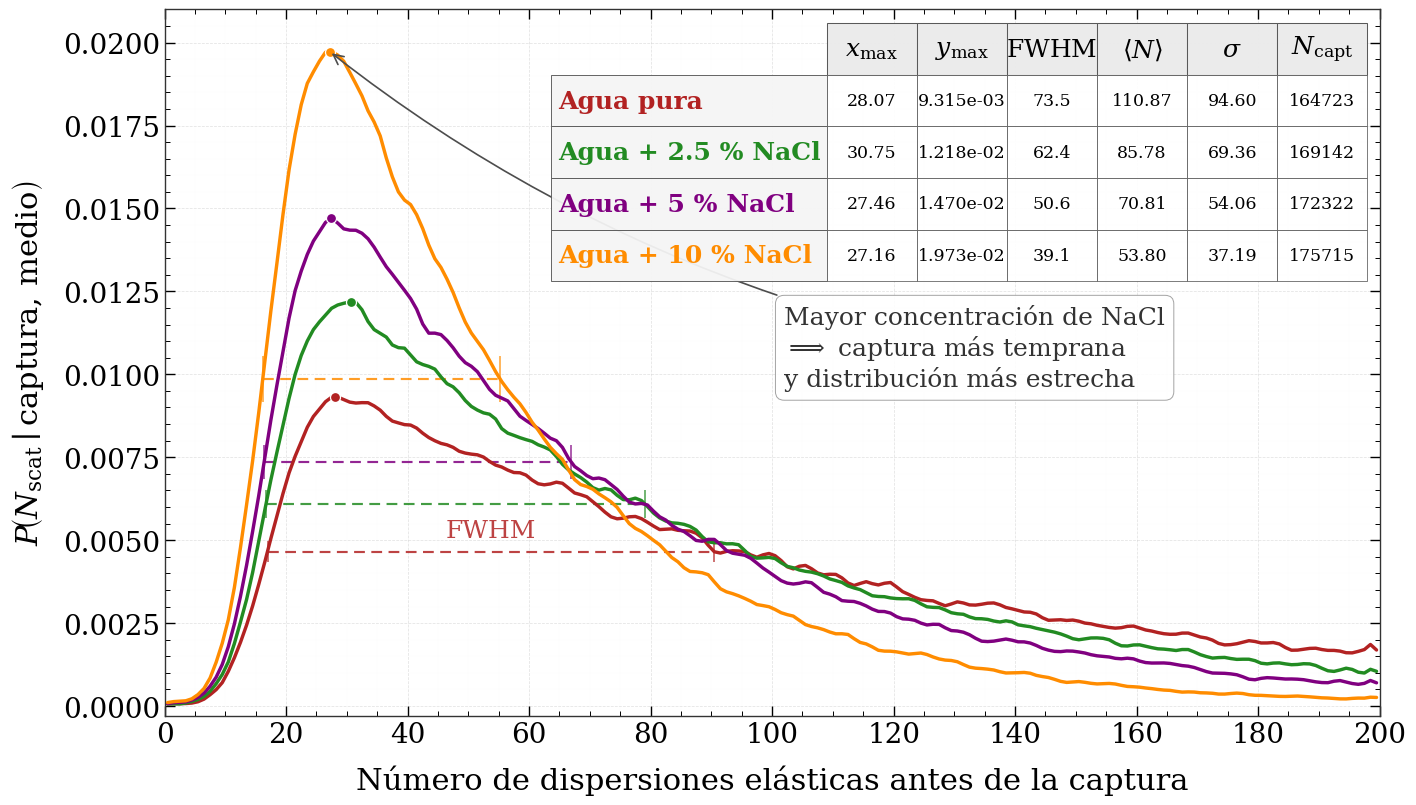


Figura generada correctamente.
Directorio de salida: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Flujo-completo-Bga/Analisis-neutrones/Graficas-dispersiones-elasticas
JPG: Graficas-dispersiones-elasticas/numero-dispersion-elastica-flujo-completo-NORMALIZADO-Bga.jpg
PDF: Graficas-dispersiones-elasticas/numero-dispersion-elastica-flujo-completo-NORMALIZADO-Bga.pdf
Resultados: Graficas-dispersiones-elasticas/numero-dispersion-elastica-flujo-completo-NORMALIZADO-Bga-resultados.txt

Resumen de resultados
---------------------

Agua pura
  x_max       = 28.0677
  y_max       = 9.315274e-03
  FWHM        = 73.5116
  <N>         = 110.8679
  sigma       = 94.5994
  N_capt      = 164,723
  límite izq. = 16.9499
  límite der. = 90.4615

Agua + 2.5 % NaCl
  x_max       = 30.7473
  y_max       = 1.218162e-02
  FWHM        = 62.3587
  <N>         = 85.7817
  sigma       = 69.3634
  N_capt      = 169,142
  límite izq. = 16.7079
  límite der. = 79.0667

Agua + 5 % NaCl
  x_max       = 27.4636

In [18]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

NUMERO_BINS = 200

INICIO = 0
FIN = 200

# ==========================================================
# DIRECTORIO Y NOMBRE BASE DE LOS ARCHIVOS DE SALIDA
# ==========================================================

# Carpeta donde se guardarán las figuras y los resultados.
DIRECTORIO_SALIDA = "Graficas-dispersiones-elasticas"

# Crear la carpeta automáticamente si todavía no existe.
os.makedirs(DIRECTORIO_SALIDA, exist_ok=True)

# Nombre base común para JPG, PDF y archivo de resultados.
NOMBRE_BASE_SALIDA = (
    "numero-dispersion-elastica-flujo-completo-"
    "NORMALIZADO-Bga"
)

# Ruta completa, sin extensión. Las extensiones se agregan
# posteriormente al guardar cada archivo.
ARCHIVO_SALIDA = os.path.join(
    DIRECTORIO_SALIDA,
    NOMBRE_BASE_SALIDA
)

# Suavizado visual ligero.
#
# El suavizado se utiliza para mostrar mejor la tendencia,
# pero los estadísticos se calculan con los datos originales.
APLICAR_SUAVIZADO = True

# Desviación estándar del núcleo gaussiano, en número de bins.
SIGMA_SUAVIZADO = 1.0

# Mostrar anotación sobre la tendencia física.
MOSTRAR_TENDENCIA = True


# ==========================================================
# CAPTURAS POR MEDIO
# ==========================================================

capturas = {
    "Agua pura": 164723,
    "Agua + 2.5 % NaCl": 169142,
    "Agua + 5 % NaCl": 172322,
    "Agua + 10 % NaCl": 175715,
}


# ==========================================================
# COLORES
# ==========================================================

COLORES = {
    "Agua pura": "firebrick",
    "Agua + 2.5 % NaCl": "forestgreen",
    "Agua + 5 % NaCl": "purple",
    "Agua + 10 % NaCl": "darkorange",
}


# ==========================================================
# CONFIGURACIÓN TIPOGRÁFICA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "font.size": 18,
    "axes.labelsize": 21,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18,

    "axes.linewidth": 1.0,

    # Mantener fuentes editables en PDF.
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# SUAVIZADO GAUSSIANO
# ==========================================================

def suavizado_gaussiano(valores, sigma=1.0):
    """
    Aplica un suavizado gaussiano unidimensional.

    No requiere scipy. El área de la distribución se conserva
    aproximadamente porque el núcleo se normaliza a la unidad.
    """

    valores = np.asarray(valores, dtype=float)

    if sigma <= 0:
        return valores.copy()

    radio = max(1, int(np.ceil(4.0 * sigma)))

    x_kernel = np.arange(
        -radio,
        radio + 1,
        dtype=float
    )

    kernel = np.exp(
        -0.5 * (x_kernel / sigma)**2
    )

    kernel /= np.sum(kernel)

    return np.convolve(
        valores,
        kernel,
        mode="same"
    )


# ==========================================================
# MÁXIMO REFINADO
# ==========================================================

def refined_peak_position(bin_centers, counts):
    """
    Refina la posición del máximo mediante un ajuste parabólico
    utilizando el bin máximo y sus dos bins vecinos.
    """

    idx = int(np.argmax(counts))

    if idx == 0 or idx == len(counts) - 1:
        return float(bin_centers[idx])

    x = bin_centers[idx - 1:idx + 2]
    y = counts[idx - 1:idx + 2]

    a, b, _ = np.polyfit(x, y, 2)

    if np.isclose(a, 0.0):
        return float(bin_centers[idx])

    x_refinado = -b / (2.0 * a)

    # Evitar que el ajuste parabólico genere una posición
    # fuera de los tres bins usados.
    return float(
        np.clip(
            x_refinado,
            x[0],
            x[-1]
        )
    )


# ==========================================================
# INTERPOLACIÓN DE CRUCES A MEDIA ALTURA
# ==========================================================

def interpolar_cruce(x1, y1, x2, y2, nivel):
    """
    Interpola linealmente la posición donde una curva cruza
    un nivel determinado.
    """

    if np.isclose(y2, y1):
        return 0.5 * (x1 + x2)

    return x1 + (
        (nivel - y1)
        * (x2 - x1)
        / (y2 - y1)
    )


# ==========================================================
# CÁLCULO DEL FWHM
# ==========================================================

def calcular_fwhm(x, y):
    """
    Calcula el ancho a media altura mediante interpolación
    lineal en los cruces izquierdo y derecho.
    """

    idx_max = int(np.argmax(y))
    y_max = float(y[idx_max])
    half_max = y_max / 2.0

    # ------------------------------------------------------
    # Cruce izquierdo
    # ------------------------------------------------------

    idx_izquierdo = None

    for i in range(idx_max, 0, -1):

        if y[i - 1] < half_max <= y[i]:
            idx_izquierdo = i
            break

    if idx_izquierdo is None:

        x_left = float(x[0])

    else:

        x_left = interpolar_cruce(
            x[idx_izquierdo - 1],
            y[idx_izquierdo - 1],
            x[idx_izquierdo],
            y[idx_izquierdo],
            half_max
        )

    # ------------------------------------------------------
    # Cruce derecho
    # ------------------------------------------------------

    idx_derecho = None

    for i in range(idx_max, len(y) - 1):

        if y[i] >= half_max > y[i + 1]:
            idx_derecho = i
            break

    if idx_derecho is None:

        x_right = float(x[-1])

    else:

        x_right = interpolar_cruce(
            x[idx_derecho],
            y[idx_derecho],
            x[idx_derecho + 1],
            y[idx_derecho + 1],
            half_max
        )

    fwhm = x_right - x_left

    return (
        float(x_left),
        float(x_right),
        float(fwhm),
        float(half_max)
    )


# ==========================================================
# FUNCIÓN DE GRAFICACIÓN Y ESTADÍSTICA
# ==========================================================

def plot_polygon_with_max_and_fwhm(
    ax,
    data,
    color,
    label,
    n_capt
):
    """
    Construye la distribución normalizada, calcula los
    estadísticos y dibuja máximo y FWHM.
    """

    data = np.asarray(data, dtype=float)

    data = data[
        np.isfinite(data)
    ]

    if data.size == 0:
        raise ValueError(
            f"No existen datos válidos para: {label}"
        )

    if n_capt <= 0:
        raise ValueError(
            f"Número de capturas no válido para: {label}"
        )

    # ======================================================
    # HISTOGRAMA
    # ======================================================

    counts, bins = np.histogram(
        data,
        bins=NUMERO_BINS,
        range=(INICIO, FIN)
    )

    bin_centers = 0.5 * (
        bins[:-1] + bins[1:]
    )

    # ======================================================
    # NORMALIZACIÓN
    # ======================================================
    #
    # P(N | captura, medio) = cuentas del bin / N_capt
    # ======================================================

    counts_norm = (
        counts.astype(float) / float(n_capt)
    )

    # Suavizado exclusivamente visual.
    if APLICAR_SUAVIZADO:

        curva_grafica = suavizado_gaussiano(
            counts_norm,
            sigma=SIGMA_SUAVIZADO
        )

    else:

        curva_grafica = counts_norm.copy()

    # ======================================================
    # ESTADÍSTICA DIRECTA DE LOS DATOS
    # ======================================================
    #
    # Se calculan media y desviación estándar directamente
    # con los eventos individuales, no con la curva suavizada.
    # ======================================================

    N_mean = float(np.mean(data))

    sigma = float(
        np.std(
            data,
            ddof=0
        )
    )

    # ======================================================
    # MÁXIMO REFINADO
    # ======================================================

    idx_max = int(
        np.argmax(curva_grafica)
    )

    y_max = float(
        curva_grafica[idx_max]
    )

    x_max = refined_peak_position(
        bin_centers,
        curva_grafica
    )

    # Para representar y_max en la posición refinada se usa
    # interpolación sobre la curva.
    y_max_refinado = float(
        np.interp(
            x_max,
            bin_centers,
            curva_grafica
        )
    )

    # ======================================================
    # FWHM
    # ======================================================

    x_left, x_right, fwhm, half_max = calcular_fwhm(
        bin_centers,
        curva_grafica
    )

    # ======================================================
    # CURVA PRINCIPAL
    # ======================================================

    ax.plot(
        bin_centers,
        curva_grafica,
        color=color,
        linewidth=2.45,
        label=label,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=4
    )

    # ======================================================
    # MARCADOR DEL MÁXIMO
    # ======================================================

    ax.plot(
        x_max,
        y_max_refinado,
        marker="o",
        markersize=7.2,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.9,
        linestyle="none",
        zorder=8
    )

    # ======================================================
    # LÍNEA DEL FWHM
    # ======================================================

    ax.hlines(
        y=half_max,
        xmin=x_left,
        xmax=x_right,
        colors=color,
        linestyles=(0, (5, 3)),
        linewidth=1.55,
        alpha=0.85,
        zorder=3
    )

    # Pequeñas marcas verticales en los extremos del FWHM.
    altura_marca = 0.035 * y_max

    ax.vlines(
        [x_left, x_right],
        ymin=half_max - altura_marca,
        ymax=half_max + altura_marca,
        colors=color,
        linewidth=1.2,
        alpha=0.75,
        zorder=3
    )

    return (
        x_max,
        y_max,
        fwhm,
        N_mean,
        sigma,
        n_capt,
        x_left,
        x_right,
        half_max
    )


# ==========================================================
# CONFIGURACIONES FÍSICAS
# ==========================================================

configuraciones = [
    (
        "Agua pura",
        datos_n_AP_1meV,
        COLORES["Agua pura"]
    ),
    (
        "Agua + 2.5 % NaCl",
        datos_n_AP_10meV,
        COLORES["Agua + 2.5 % NaCl"]
    ),
    (
        "Agua + 5 % NaCl",
        datos_n_AP_100meV,
        COLORES["Agua + 5 % NaCl"]
    ),
    (
        "Agua + 10 % NaCl",
        datos_n_AP_1000meV,
        COLORES["Agua + 10 % NaCl"]
    ),
]


# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, ax = plt.subplots(
    figsize=(14.5, 8.4)
)

resultados = []


# ==========================================================
# GRAFICAR LAS CONFIGURACIONES
# ==========================================================

for nombre, datos, color in configuraciones:

    resultado = plot_polygon_with_max_and_fwhm(
        ax=ax,
        data=datos,
        color=color,
        label=nombre,
        n_capt=capturas[nombre]
    )

    resultados.append(
        (
            nombre,
            *resultado
        )
    )


# ==========================================================
# FORMATO DE LOS EJES
# ==========================================================

ax.set_xlabel(
    "Número de dispersiones elásticas antes de la captura",
    fontsize=22,
    labelpad=12
)

ax.set_ylabel(
    r"$P\!\left("
    r"N_{\mathrm{scat}}"
    r"\mid"
    r"\mathrm{captura},\,"
    r"\mathrm{medio}"
    r"\right)$",
    fontsize=22,
    labelpad=12
)

ax.set_xlim(
    INICIO,
    FIN
)

ax.set_xticks(
    np.arange(
        INICIO,
        FIN + 1,
        20
    )
)

# Formato decimal uniforme del eje vertical.
ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.4f")
)

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=7,
    width=1.0,
    labelsize=20,
    top=True,
    right=True
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3.5,
    width=0.7,
    top=True,
    right=True
)

ax.minorticks_on()


# ==========================================================
# CUADRÍCULA
# ==========================================================

ax.grid(
    visible=True,
    which="major",
    linestyle="--",
    linewidth=0.55,
    alpha=0.35
)

ax.grid(
    visible=True,
    which="minor",
    linestyle=":",
    linewidth=0.30,
    alpha=0.10
)

ax.set_axisbelow(True)


# ==========================================================
# TABLA DE RESULTADOS
# ==========================================================

table_data = [
    [
        f"{x_max:.2f}",
        f"{y_max:.3e}",
        f"{fwhm:.1f}",
        f"{N_mean:.2f}",
        f"{sigma:.2f}",
        f"{n_capt:}"
    ]
    for (
        _,
        x_max,
        y_max,
        fwhm,
        N_mean,
        sigma,
        n_capt,
        _,
        _,
        _
    ) in resultados
]

row_labels = [
    resultado[0]
    for resultado in resultados
]

col_labels = [
    r"$x_{\max}$",
    r"$y_{\max}$",
    r"$\mathrm{FWHM}$",
    r"$\langle N\rangle$",
    r"$\sigma$",
    r"$N_{\mathrm{capt}}$"
]

tabla = ax.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,

    # Tabla más pequeña y desplazada hacia arriba-derecha.
    bbox=[
        0.545,
        0.615,
        0.445,
        0.365
    ],

    colLoc="center",
    cellLoc="center",

    zorder=20
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(12.5)


# ==========================================================
# FORMATO GENERAL DE LA TABLA
# ==========================================================

cells = tabla.get_celld()

for (row, column), cell in cells.items():

    cell.set_edgecolor("0.35")
    cell.set_linewidth(0.55)

    # Fondo blanco ligeramente transparente.
    cell.set_facecolor(
        (1.0, 1.0, 1.0, 0.92)
    )

    cell.PAD = 0.025


# ==========================================================
# FORMATO DEL ENCABEZADO
# ==========================================================

for column in range(
    len(col_labels)
):

    cell = cells[(0, column)]

    cell.set_facecolor(
        (0.92, 0.92, 0.92, 0.96)
    )

    cell.set_text_props(
        weight="bold",
        color="black",
        fontsize=18
    )

    cell.set_linewidth(0.75)


# ==========================================================
# ETIQUETAS DE LAS FILAS
# ==========================================================

for row_index, (
    nombre,
    _,
    color
) in enumerate(
    configuraciones,
    start=1
):

    row_label_cell = cells[
        (row_index, -1)
    ]

    row_label_cell.set_text_props(
        color=color,
        weight="bold",
        fontsize=18
    )

    row_label_cell.set_facecolor(
        (0.96, 0.96, 0.96, 0.94)
    )

    row_label_cell.set_linewidth(0.65)


# ==========================================================
# ANOTACIÓN DE LA TENDENCIA FÍSICA
# ==========================================================

if MOSTRAR_TENDENCIA:

    ax.annotate(
        (
            "Mayor concentración de NaCl\n"
            r"$\Longrightarrow$ captura más temprana"
            "\ny distribución más estrecha"
        ),

        xy=(
            resultados[-1][1],
            resultados[-1][2]
        ),

        xytext=(
            102,
            0.0108
        ),

        fontsize=18,
        ha="left",
        va="center",
        color="0.20",

        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.2,
            color="0.30",
            connectionstyle="arc3,rad=-0.12"
        ),

        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="0.60",
            linewidth=0.7,
            alpha=0.90
        ),

        zorder=15
    )


# ==========================================================
# INDICACIÓN DISCRETA DEL FWHM
# ==========================================================

# Se toma la primera distribución como ejemplo.
primer_resultado = resultados[0]

x_left_agua = primer_resultado[7]
x_right_agua = primer_resultado[8]
half_max_agua = primer_resultado[9]

ax.text(
    0.5 * (
        x_left_agua + x_right_agua
    ),
    half_max_agua * 1.06,
    "FWHM",
    color=COLORES["Agua pura"],
    fontsize=18,
    ha="center",
    va="bottom",
    alpha=0.85,
    zorder=7
)


# ==========================================================
# BORDES DE LA FIGURA
# ==========================================================

for spine in ax.spines.values():

    spine.set_linewidth(1.0)
    spine.set_color("0.20")


# ==========================================================
# AJUSTAR LÍMITE VERTICAL
# ==========================================================

# Se deja espacio suficiente para la tabla.
maximo_global = max(
    resultado[2]
    for resultado in resultados
)

ax.set_ylim(
    bottom=-0.0003,
    top=maximo_global * 1.065
)


# ==========================================================
# GUARDAR RESULTADOS NUMÉRICOS
# ==========================================================

archivo_resultados = (
    ARCHIVO_SALIDA
    + "-resultados.txt"
)

with open(
    archivo_resultados,
    "w",
    encoding="utf-8"
) as archivo:

    archivo.write(
        "# Resultados de las distribuciones normalizadas\n"
    )

    archivo.write(
        "# P(N | captura, medio)\n"
    )

    archivo.write(
        "#\n"
    )

    archivo.write(
        "# Medio\t"
        "x_max\t"
        "y_max\t"
        "FWHM\t"
        "N_mean\t"
        "sigma\t"
        "N_capt\t"
        "x_left_FWHM\t"
        "x_right_FWHM\n"
    )

    for (
        nombre,
        x_max,
        y_max,
        fwhm,
        N_mean,
        sigma,
        n_capt,
        x_left,
        x_right,
        _
    ) in resultados:

        archivo.write(
            f"{nombre}\t"
            f"{x_max:.8f}\t"
            f"{y_max:.10e}\t"
            f"{fwhm:.8f}\t"
            f"{N_mean:.8f}\t"
            f"{sigma:.8f}\t"
            f"{n_capt:d}\t"
            f"{x_left:.8f}\t"
            f"{x_right:.8f}\n"
        )


# ==========================================================
# GUARDAR FIGURA
# ==========================================================

fig.tight_layout()

fig.savefig(
    ARCHIVO_SALIDA + ".jpg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05
)

fig.savefig(
    ARCHIVO_SALIDA + ".pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()
plt.close(fig)


# ==========================================================
# INFORMACIÓN EN TERMINAL
# ==========================================================

print("\nFigura generada correctamente.")
print(f"Directorio de salida: {os.path.abspath(DIRECTORIO_SALIDA)}")
print(f"JPG: {ARCHIVO_SALIDA}.jpg")
print(f"PDF: {ARCHIVO_SALIDA}.pdf")
print(f"Resultados: {archivo_resultados}")

print("\nResumen de resultados")
print("---------------------")

for (
    nombre,
    x_max,
    y_max,
    fwhm,
    N_mean,
    sigma,
    n_capt,
    x_left,
    x_right,
    _
) in resultados:

    print(f"\n{nombre}")
    print(f"  x_max       = {x_max:.4f}")
    print(f"  y_max       = {y_max:.6e}")
    print(f"  FWHM        = {fwhm:.4f}")
    print(f"  <N>         = {N_mean:.4f}")
    print(f"  sigma       = {sigma:.4f}")
    print(f"  N_capt      = {n_capt:,}")
    print(f"  límite izq. = {x_left:.4f}")
    print(f"  límite der. = {x_right:.4f}")

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Modelo exponencial ---
def expo(x, A, tau):
    return A * np.exp(-x / tau)

# --- Función para cargar datos de dispersión ---
def cargar_datos(filename, bins=200):
    # Cargar todos los números del archivo
    data = np.loadtxt(filename)
    # Histograma (como cuentas por número de dispersión)
    counts, bin_edges = np.histogram(data, bins=bins, range=(0,200))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_centers, counts

# ============================
# Archivos
# ============================
archivos = {
    "Agua pura": "../Agua-pura/numero-dispersiones-elasticas-AP-termicos-Bga.txt",
    "Agua + 2.5% NaCl": "../Agua+2.5NaCl/numero-dispersiones-elasticas-A-25NaCl-termicos-Bga.txt",
    "Agua + 5% NaCl": "../Agua+5NaCl/numero-dispersiones-elasticas-A-5NaCl-termicos-Bga.txt",
    "Agua + 10% NaCl": "../Agua+10NaCl/numero-dispersiones-elasticas-A-10NaCl-termicos-Bga.txt"
}

colores = ["red", "green", "purple", "orange"]

# ============================
# Ajuste y graficación
# ============================
plt.figure(figsize=(12,8))

for (label, archivo), color in zip(archivos.items(), colores):
    # Cargar datos en histograma
    x, y = cargar_datos(archivo, bins=200)
    
    # Evitar ceros
    mask = y > 0
    x_fit, y_fit = x[mask], y[mask]
    
    # Ajuste exponencial
    popt, pcov = curve_fit(expo, x_fit, y_fit, p0=(y_fit[0], 20))
    A, tau = popt
    
    # Dibujar datos originales
    plt.plot(x, y, color=color, alpha=0.7, label=f"{label} (datos)")
    
    # Dibujar ajuste
    plt.plot(x, expo(x, *popt), "--", color=color, linewidth=2, 
             label=f"{label} ajuste τ={tau:.2f}")
    
    # Mostrar parámetros en consola
    print(f"{label}: A={A:.1f}, tau={tau:.2f}")

# Etiquetas
plt.xlabel("Número de dispersiones elásticas", fontsize=18)
plt.ylabel("Cuentas [u.a.]", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


FileNotFoundError: ../Agua-pura/numero-dispersiones-elasticas-AP-termicos-Bga.txt not found.

<Figure size 1200x800 with 0 Axes>

# Histogramas agua pura (Cita)

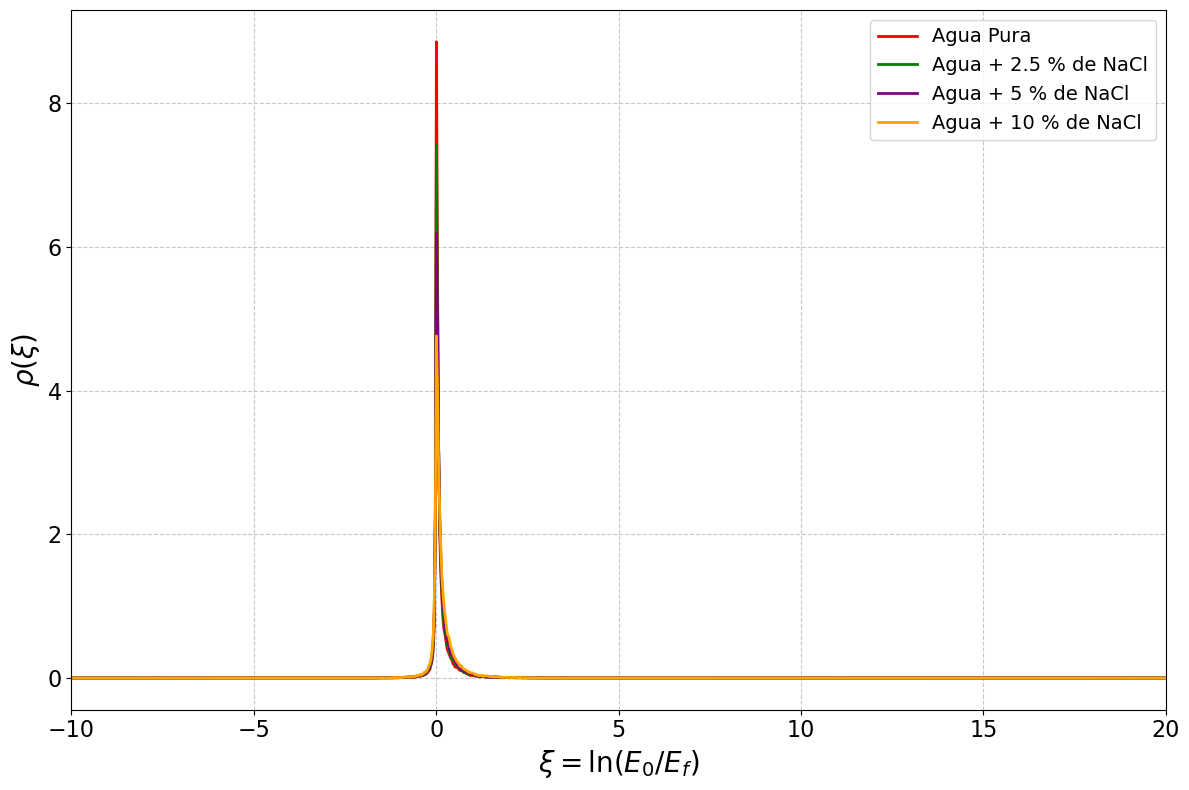

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # aquí seleccionas la COLUMNA (ej: col3 = índice 2)
                except:
                    continue
    data = np.array(data)
    data = data[~np.isnan(data)]  # quitar nan
    
    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../Agua-pura/cita-AP-termicos-Bga.txt", "red",    "Agua Pura"),
    ("../Agua+2.5NaCl/cita-A-25NaCl-termicos-Bga.txt", "green", "Agua + 2.5 % de NaCl"),
    ("../Agua+5NaCl/cita-A-5NaCl-termicos-Bga.txt", "purple","Agua + 5 % de NaCl"),
    ("../Agua+10NaCl/cita-A-10NaCl-termicos-Bga.txt", "orange","Agua + 10 % de NaCl")

]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-termicos-Bga.pdf", format="pdf")
plt.savefig("Cita-neutron-termicos-Bga.png", format="png")
plt.show()


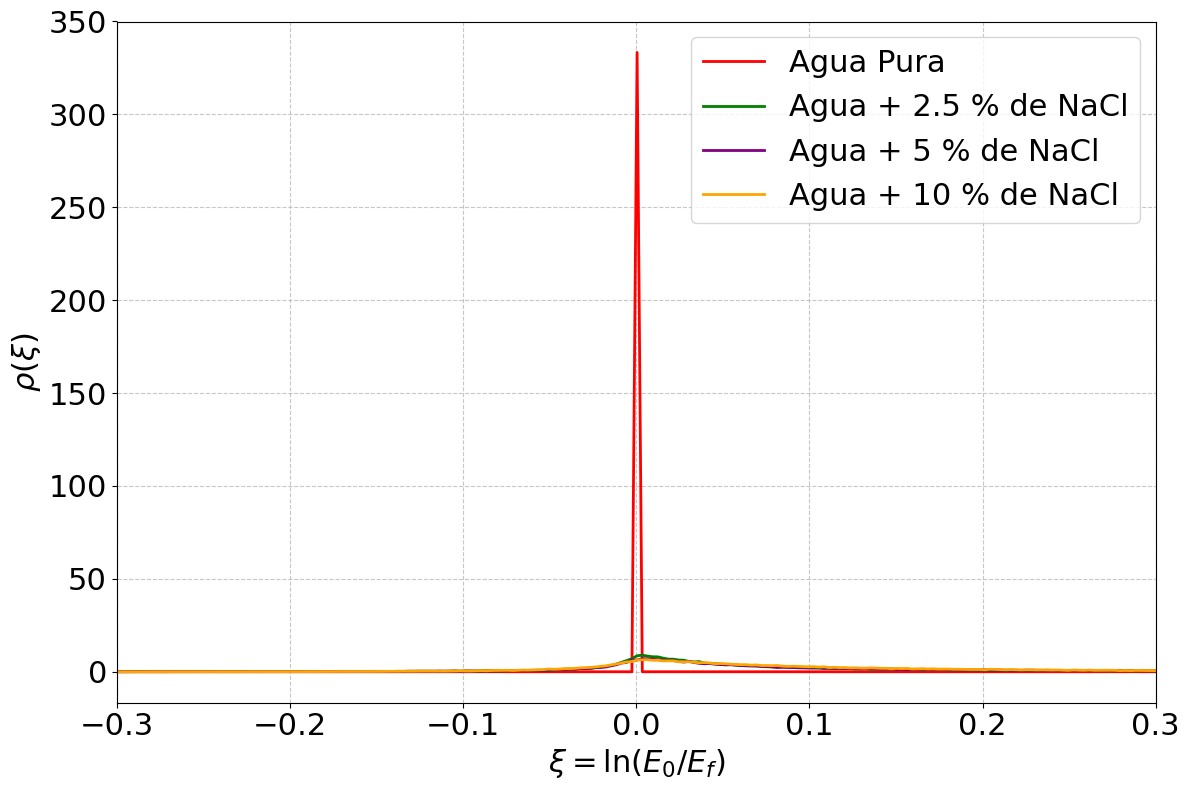

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../Agua-pura/cita-AP-termicos-Bga.txt", "red",    "Agua Pura"),
    ("../Agua+2.5NaCl/cita-A-25NaCl-termicos-Bga.txt", "green", "Agua + 2.5 % de NaCl"),
    ("../Agua+5NaCl/cita-A-5NaCl-termicos-Bga.txt", "purple","Agua + 5 % de NaCl"),
    ("../Agua+10NaCl/cita-A-10NaCl-termicos-Bga.txt", "orange","Agua + 10 % de NaCl")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=10000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=22)
plt.ylabel(r"$\rho(\xi)$", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=22)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-termicos-Bga.pdf", format="pdf")
plt.savefig("Cita-neutron-termicos-Bga.png", format="png")
plt.show()


Agua Pura: media = 0.1067, desviación estándar = 0.2673
Agua + 2.5 % de NaCl: media = 0.1212, desviación estándar = 0.2957
Agua + 5 % de NaCl: media = 0.1356, desviación estándar = 0.3134
Agua + 10 % de NaCl: media = 0.1621, desviación estándar = 0.3501


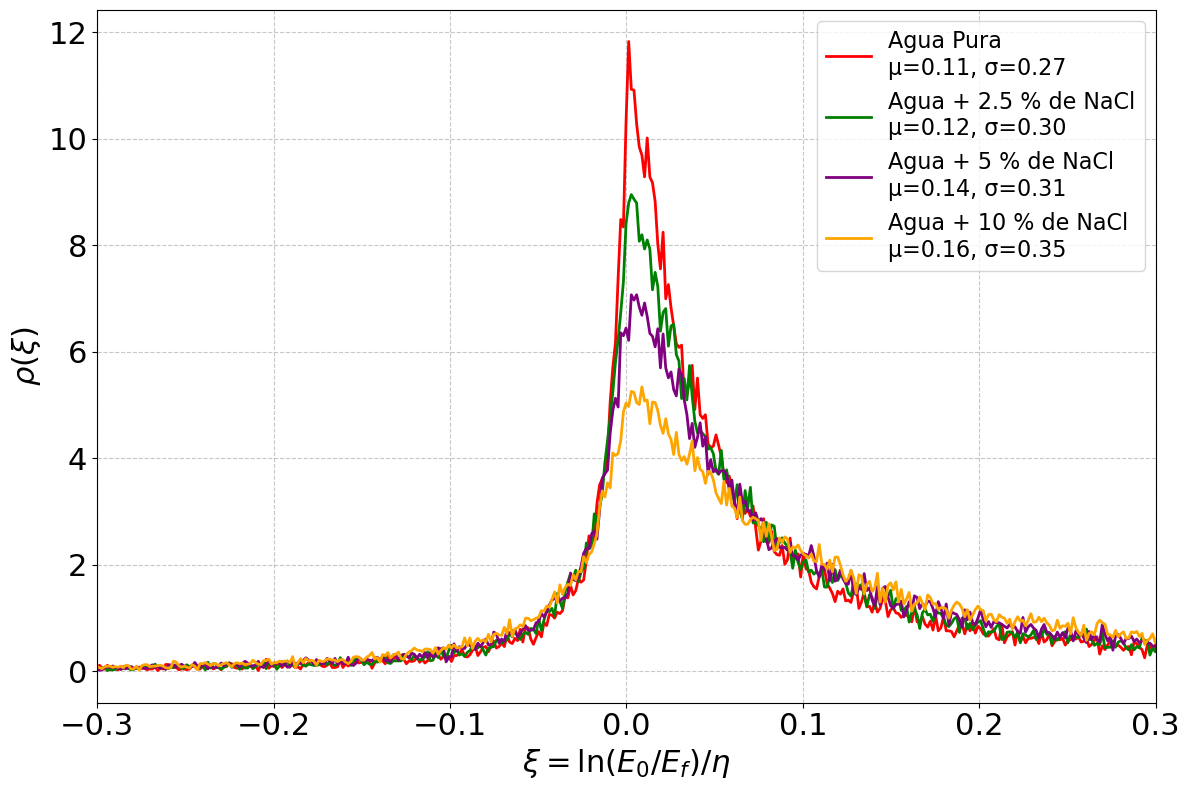

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../Agua-pura/cita-AP-termicos-Bga.txt", "red",    "Agua Pura"),
    ("../Agua+2.5NaCl/cita-A-25NaCl-termicos-Bga.txt", "green", "Agua + 2.5 % de NaCl"),
    ("../Agua+5NaCl/cita-A-5NaCl-termicos-Bga.txt", "purple","Agua + 5 % de NaCl"),
    ("../Agua+10NaCl/cita-A-10NaCl-termicos-Bga.txt", "orange","Agua + 10 % de NaCl")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=20000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel(r"$\rho(\xi)$", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-termicos-Bga.pdf", format="pdf")
plt.savefig("Cita-neutron-termicos-Bga.png", format="png")
plt.show()


# Histogramas agua + 2.5 % de sal

In [148]:
# Nombre del archivo de datos
archivo_datos = "../1meV/Agua+2.5NaCl/numero-dispersiones-elasticas-1meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_1meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_1meV.append(valor)

In [150]:
# Nombre del archivo de datos
archivo_datos = "../10meV/Agua+2.5NaCl/numero-dispersiones-elasticas-10meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_10meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_10meV.append(valor)

In [152]:
# Nombre del archivo de datos
archivo_datos = "../100meV/Agua+2.5NaCl/numero-dispersiones-elasticas-100meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_100meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_100meV.append(valor)

In [154]:
# Nombre del archivo de datos
archivo_datos = "../1000meV/Agua+2.5NaCl/numero-dispersiones-elasticas-1000meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_1000meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_1000meV.append(valor)

In [156]:
# Nombre del archivo de datos
archivo_datos = "../10000meV/Agua+2.5NaCl/numero-dispersiones-elasticas-10000meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_10000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_10000meV.append(valor)

In [158]:
# Nombre del archivo de datos
archivo_datos = "../100000meV/Agua+2.5NaCl/numero-dispersiones-elasticas-100000meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_100000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_100000meV.append(valor)

In [160]:
# Nombre del archivo de datos
archivo_datos = "../1000000meV/Agua+2.5NaCl/numero-dispersiones-elasticas-1000000meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_1000000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_1000000meV.append(valor)

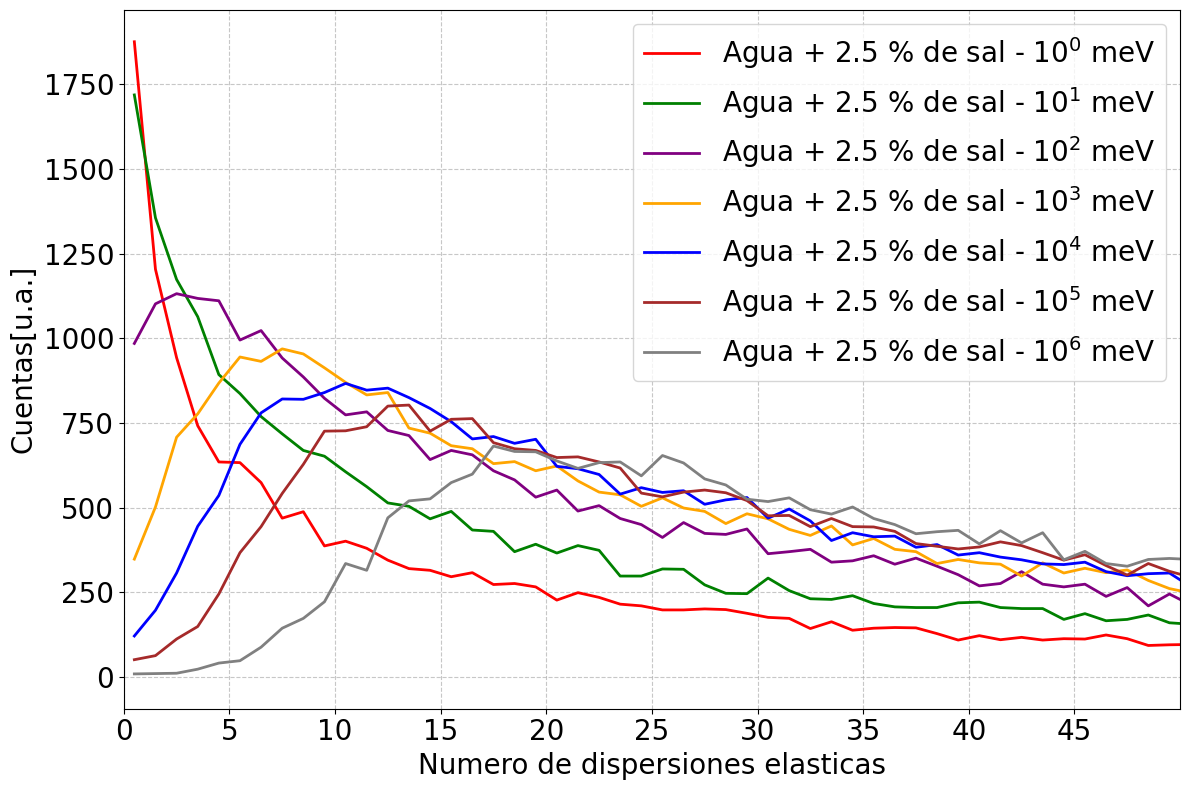

In [250]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 300
inicio, fin = 0, 300

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_A_25NaCl_1meV, color='red', label='Agua + 2.5 % de sal - $10^{0}$ meV')
plot_polygon(datos_n_A_25NaCl_10meV, color='green', label='Agua + 2.5 % de sal - $10^{1}$ meV')
plot_polygon(datos_n_A_25NaCl_100meV, color='purple', label='Agua + 2.5 % de sal - $10^{2}$ meV')
plot_polygon(datos_n_A_25NaCl_1000meV, color='orange', label='Agua + 2.5 % de sal - $10^{3}$ meV')
plot_polygon(datos_n_A_25NaCl_10000meV, color='blue', label='Agua + 2.5 % de sal - $10^{4}$ meV')
plot_polygon(datos_n_A_25NaCl_100000meV, color='brown', label='Agua + 2.5 % de sal - $10^{5}$ meV')
plot_polygon(datos_n_A_25NaCl_1000000meV, color='grey', label='Agua + 2.5 % de sal - $10^{6}$ meV')

# Agregar etiquetas y formato
plt.xlabel('Numero de dispersiones elasticas', fontsize=20)
plt.ylabel('Cuentas[u.a.]', fontsize=20)
#plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50, 5))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-Agua-25NaCl.jpg', format='jpg')
plt.savefig('numero-dispersion-elastica-neutron-Agua-25NaCl.pdf', format='pdf')
plt.show()



# Histogramas agua + 2.5 % de NaCl (Cita)

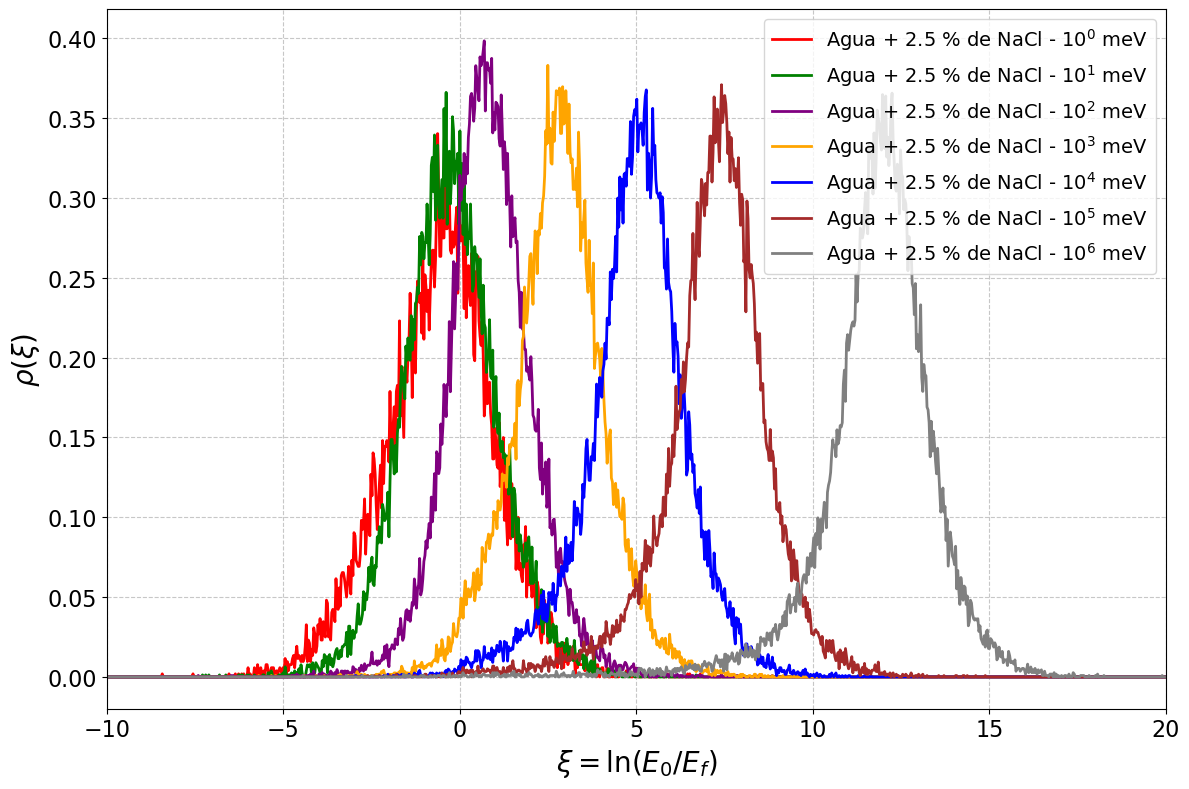

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+2.5NaCl/cita-1meV-A-25NaCl.txt", "red",    "Agua + 2.5 % de NaCl - $10^{0}$ meV"),
    ("../10meV/Agua+2.5NaCl/cita-10meV-A-25NaCl.txt", "green", "Agua + 2.5 % de NaCl - $10^{1}$ meV"),
    ("../100meV/Agua+2.5NaCl/cita-100meV-A-25NaCl.txt", "purple","Agua + 2.5 % de NaCl - $10^{2}$ meV"),
    ("../1000meV/Agua+2.5NaCl/cita-1000meV-A-25NaCl.txt", "orange","Agua + 2.5 % de NaCl - $10^{3}$ meV"),
    ("../10000meV/Agua+2.5NaCl/cita-10000meV-A-25NaCl.txt", "blue","Agua + 2.5 % de NaCl - $10^{4}$ meV"),
    ("../100000meV/Agua+2.5NaCl/cita-100000meV-A-25NaCl.txt", "brown","Agua + 2.5 % de NaCl - $10^{5}$ meV"),
    ("../1000000meV/Agua+2.5NaCl/cita-1000000meV-A-25NaCl.txt", "grey","Agua + 2.5 % de NaCl - $10^{6}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-Agua-25NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-Agua-25NaCl.png", format="png")
plt.show()


# Histogramas agua + 5 % de sal

In [180]:
# Nombre del archivo de datos
archivo_datos = "../1meV/Agua+5NaCl/numero-dispersiones-elasticas-1meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_1meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_1meV.append(valor)

In [182]:
# Nombre del archivo de datos
archivo_datos = "../10meV/Agua+5NaCl/numero-dispersiones-elasticas-10meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_10meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_10meV.append(valor)

In [184]:
# Nombre del archivo de datos
archivo_datos = "../100meV/Agua+5NaCl/numero-dispersiones-elasticas-100meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_100meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_100meV.append(valor)

In [186]:
# Nombre del archivo de datos
archivo_datos = "../1000meV/Agua+5NaCl/numero-dispersiones-elasticas-1000meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_1000meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_1000meV.append(valor)

In [188]:
# Nombre del archivo de datos
archivo_datos = "../10000meV/Agua+5NaCl/numero-dispersiones-elasticas-10000meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_10000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_10000meV.append(valor)

In [190]:
# Nombre del archivo de datos
archivo_datos = "../100000meV/Agua+5NaCl/numero-dispersiones-elasticas-100000meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_100000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_100000meV.append(valor)

In [192]:
# Nombre del archivo de datos
archivo_datos = "../1000000meV/Agua+5NaCl/numero-dispersiones-elasticas-1000000meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_1000000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_1000000meV.append(valor)

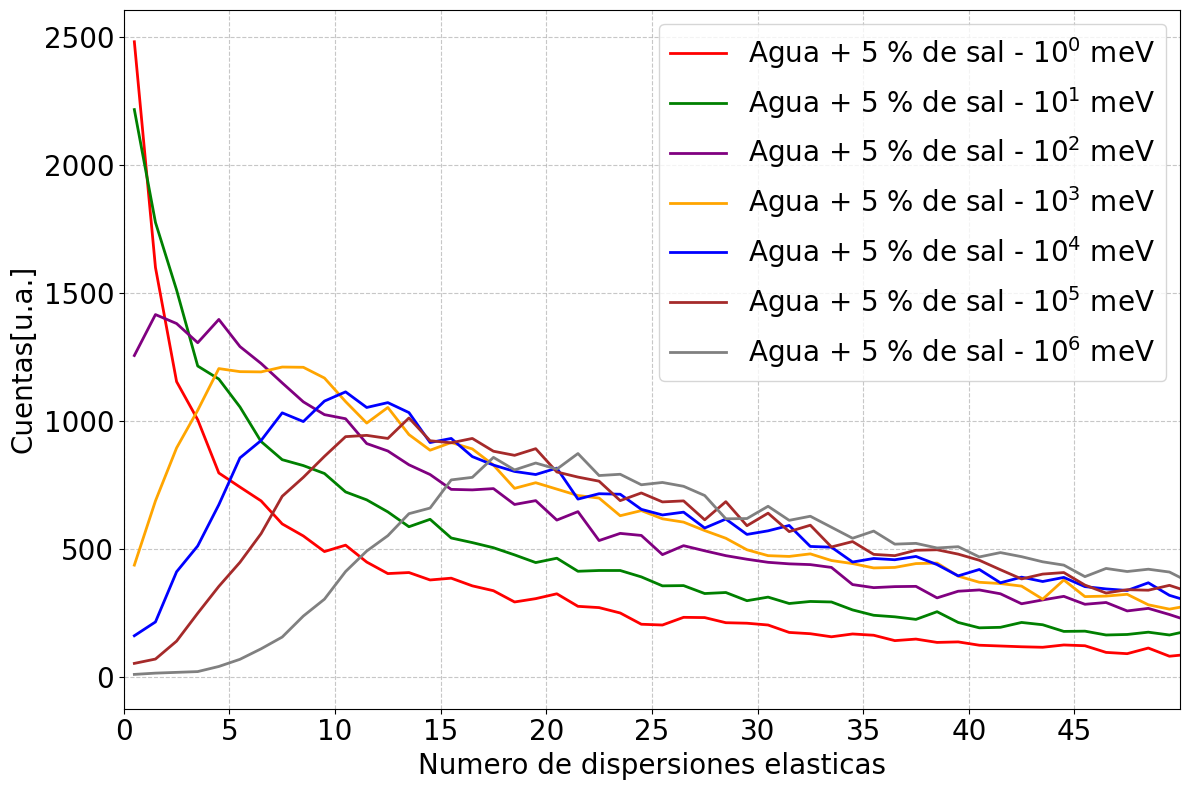

In [254]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_A_5NaCl_1meV, color='red', label='Agua + 5 % de sal - $10^{0}$ meV')
plot_polygon(datos_n_A_5NaCl_10meV, color='green', label='Agua + 5 % de sal - $10^{1}$ meV')
plot_polygon(datos_n_A_5NaCl_100meV, color='purple', label='Agua + 5 % de sal - $10^{2}$ meV')
plot_polygon(datos_n_A_5NaCl_1000meV, color='orange', label='Agua + 5 % de sal - $10^{3}$ meV')
plot_polygon(datos_n_A_5NaCl_10000meV, color='blue', label='Agua + 5 % de sal - $10^{4}$ meV')
plot_polygon(datos_n_A_5NaCl_100000meV, color='brown', label='Agua + 5 % de sal - $10^{5}$ meV')
plot_polygon(datos_n_A_5NaCl_1000000meV, color='grey', label='Agua + 5 % de sal - $10^{6}$ meV')

# Agregar etiquetas y formato
plt.xlabel('Numero de dispersiones elasticas', fontsize=20)
plt.ylabel('Cuentas[u.a.]', fontsize=20)
#plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50, 5))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-Agua-5NaCl.jpg', format='jpg')
plt.savefig('numero-dispersion-elastica-neutron-Agua-5NaCl.pdf', format='pdf')
plt.show()



In [ ]:
# Histogramas agua + 5 % de NaCl (Cita)

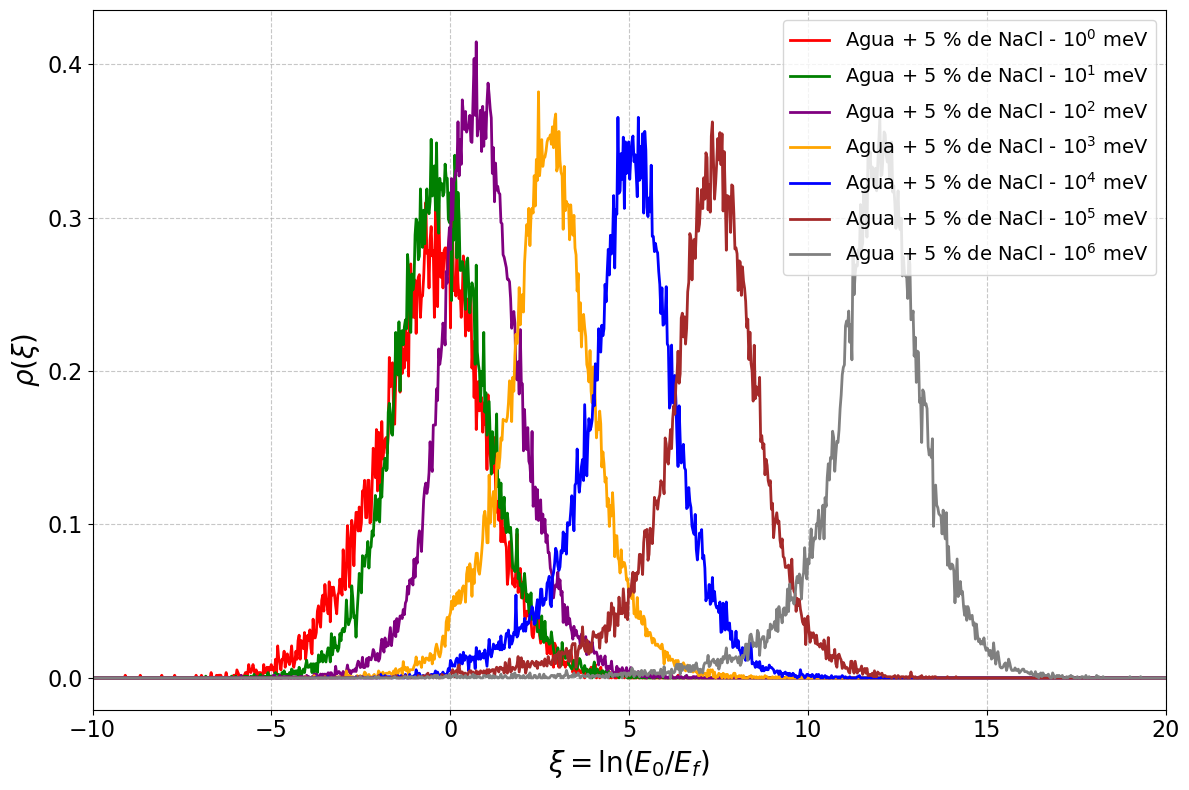

In [199]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+5NaCl/cita-1meV-A-5NaCl.txt", "red",    "Agua + 5 % de NaCl - $10^{0}$ meV"),
    ("../10meV/Agua+5NaCl/cita-10meV-A-5NaCl.txt", "green", "Agua + 5 % de NaCl - $10^{1}$ meV"),
    ("../100meV/Agua+5NaCl/cita-100meV-A-5NaCl.txt", "purple","Agua + 5 % de NaCl - $10^{2}$ meV"),
    ("../1000meV/Agua+5NaCl/cita-1000meV-A-5NaCl.txt", "orange","Agua + 5 % de NaCl - $10^{3}$ meV"),
    ("../10000meV/Agua+5NaCl/cita-10000meV-A-5NaCl.txt", "blue","Agua + 5 % de NaCl - $10^{4}$ meV"),
    ("../100000meV/Agua+5NaCl/cita-100000meV-A-5NaCl.txt", "brown","Agua + 5 % de NaCl - $10^{5}$ meV"),
    ("../1000000meV/Agua+5NaCl/cita-1000000meV-A-5NaCl.txt", "grey","Agua + 5 % de NaCl - $10^{6}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-Agua-5NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-Agua-5NaCl.png", format="png")
plt.show()


# Histogramas agua + 10 % de sal

In [201]:
# Nombre del archivo de datos
archivo_datos = "../1meV/Agua+10NaCl/numero-dispersiones-elasticas-1meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_1meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_1meV.append(valor)

In [203]:
# Nombre del archivo de datos
archivo_datos = "../10meV/Agua+10NaCl/numero-dispersiones-elasticas-10meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_10meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_10meV.append(valor)

In [205]:
# Nombre del archivo de datos
archivo_datos = "../100meV/Agua+10NaCl/numero-dispersiones-elasticas-100meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_100meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_100meV.append(valor)

In [207]:
# Nombre del archivo de datos
archivo_datos = "../1000meV/Agua+10NaCl/numero-dispersiones-elasticas-1000meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_1000meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_1000meV.append(valor)

In [220]:
# Nombre del archivo de datos
archivo_datos = "../10000meV/Agua+10NaCl/numero-dispersiones-elasticas-10000meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_10000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_10000meV.append(valor)

In [222]:
# Nombre del archivo de datos
archivo_datos = "../100000meV/Agua+10NaCl/numero-dispersiones-elasticas-100000meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_100000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_100000meV.append(valor)

In [213]:
# Nombre del archivo de datos
archivo_datos = "../1000000meV/Agua+10NaCl/numero-dispersiones-elasticas-1000000meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_1000000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_1000000meV.append(valor)

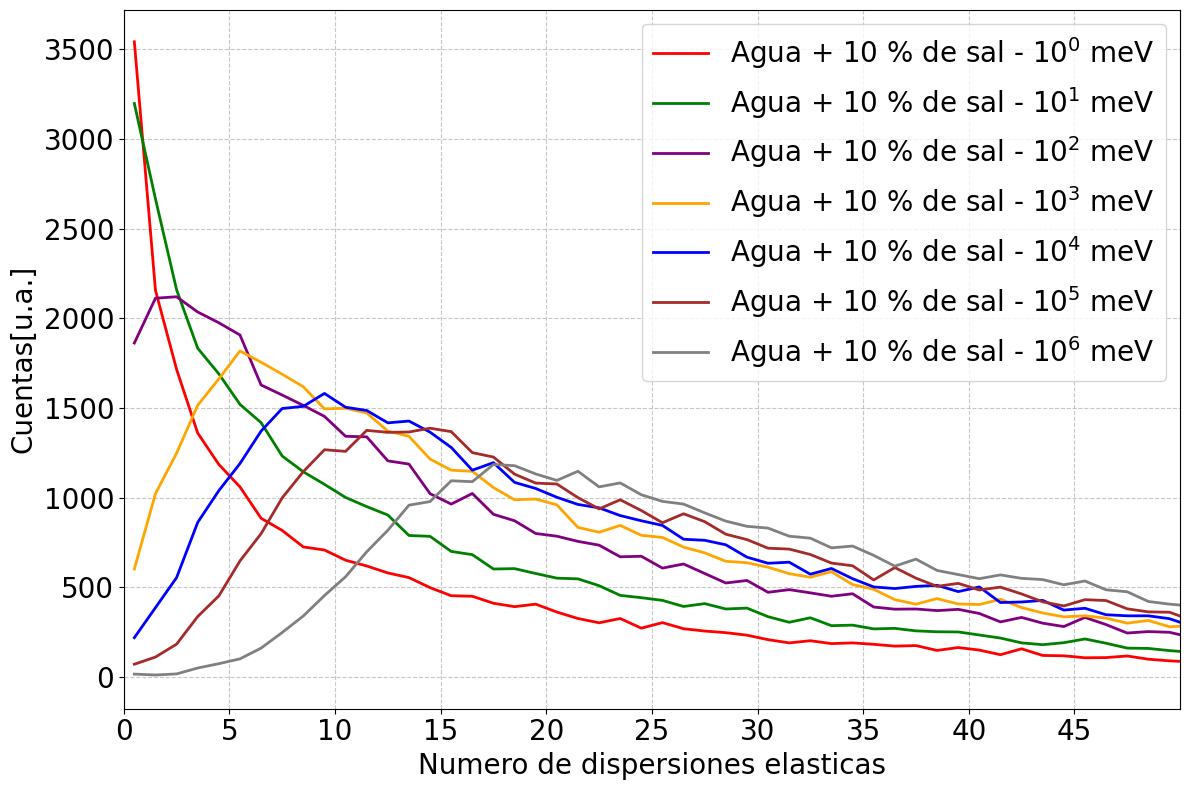

In [256]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_A_10NaCl_1meV, color='red', label='Agua + 10 % de sal - $10^{0}$ meV')
plot_polygon(datos_n_A_10NaCl_10meV, color='green', label='Agua + 10 % de sal - $10^{1}$ meV')
plot_polygon(datos_n_A_10NaCl_100meV, color='purple', label='Agua + 10 % de sal - $10^{2}$ meV')
plot_polygon(datos_n_A_10NaCl_1000meV, color='orange', label='Agua + 10 % de sal - $10^{3}$ meV')
plot_polygon(datos_n_A_10NaCl_10000meV, color='blue', label='Agua + 10 % de sal - $10^{4}$ meV')
plot_polygon(datos_n_A_10NaCl_100000meV, color='brown', label='Agua + 10 % de sal - $10^{5}$ meV')
plot_polygon(datos_n_A_10NaCl_1000000meV, color='grey', label='Agua + 10 % de sal - $10^{6}$ meV')

# Agregar etiquetas y formato
plt.xlabel('Numero de dispersiones elasticas', fontsize=20)
plt.ylabel('Cuentas[u.a.]', fontsize=20)
#plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50, 5))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-Agua-10NaCl.jpg', format='jpg')
plt.savefig('numero-dispersion-elastica-neutron-Agua-10NaCl.pdf', format='pdf')
plt.show()



# Histogramas agua + 10 % de NaCl (Cita)

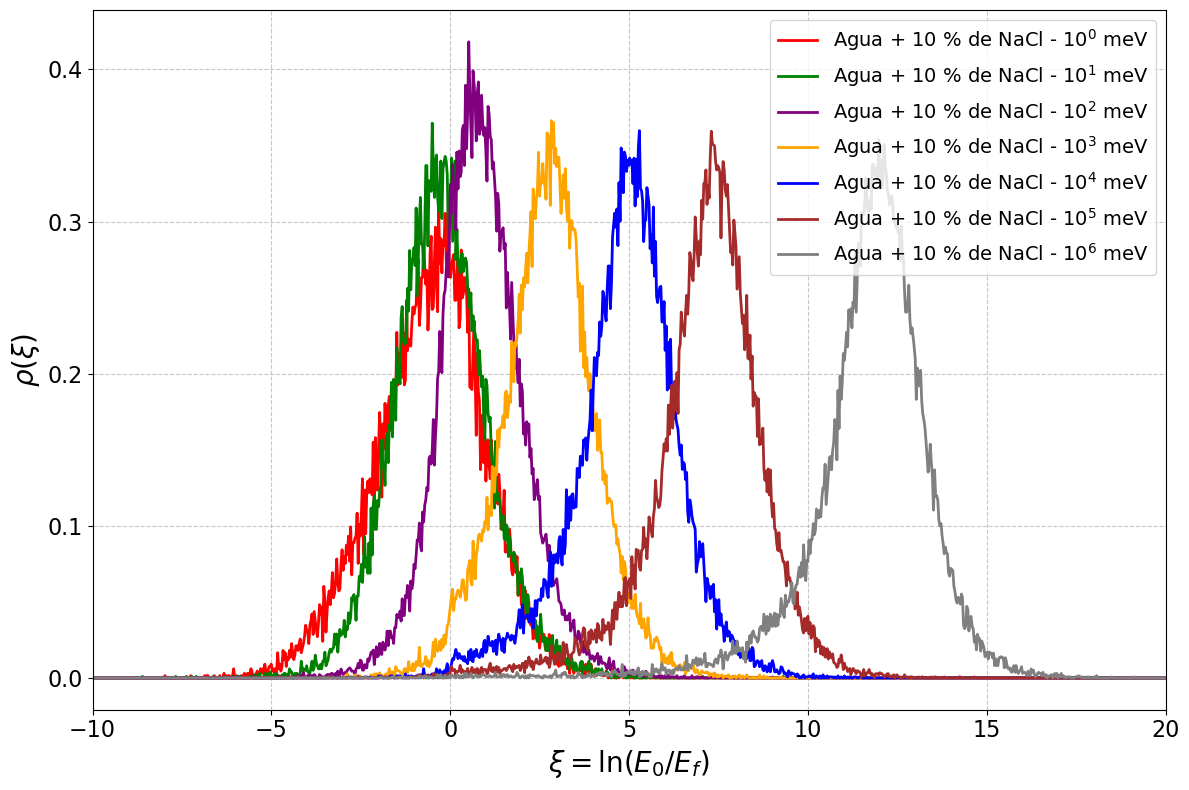

In [226]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+10NaCl/cita-1meV-A-10NaCl.txt", "red",    "Agua + 10 % de NaCl - $10^{0}$ meV"),
    ("../10meV/Agua+10NaCl/cita-10meV-A-10NaCl.txt", "green", "Agua + 10 % de NaCl - $10^{1}$ meV"),
    ("../100meV/Agua+10NaCl/cita-100meV-A-10NaCl.txt", "purple","Agua + 10 % de NaCl - $10^{2}$ meV"),
    ("../1000meV/Agua+10NaCl/cita-1000meV-A-10NaCl.txt", "orange","Agua + 10 % de NaCl - $10^{3}$ meV"),
    ("../10000meV/Agua+10NaCl/cita-10000meV-A-10NaCl.txt", "blue","Agua + 10 % de NaCl - $10^{4}$ meV"),
    ("../100000meV/Agua+10NaCl/cita-100000meV-A-10NaCl.txt", "brown","Agua + 10 % de NaCl - $10^{5}$ meV"),
    ("../1000000meV/Agua+10NaCl/cita-1000000meV-A-10NaCl.txt", "grey","Agua + 10 % de NaCl - $10^{6}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-Agua-10NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-Agua-10NaCl.png", format="png")
plt.show()


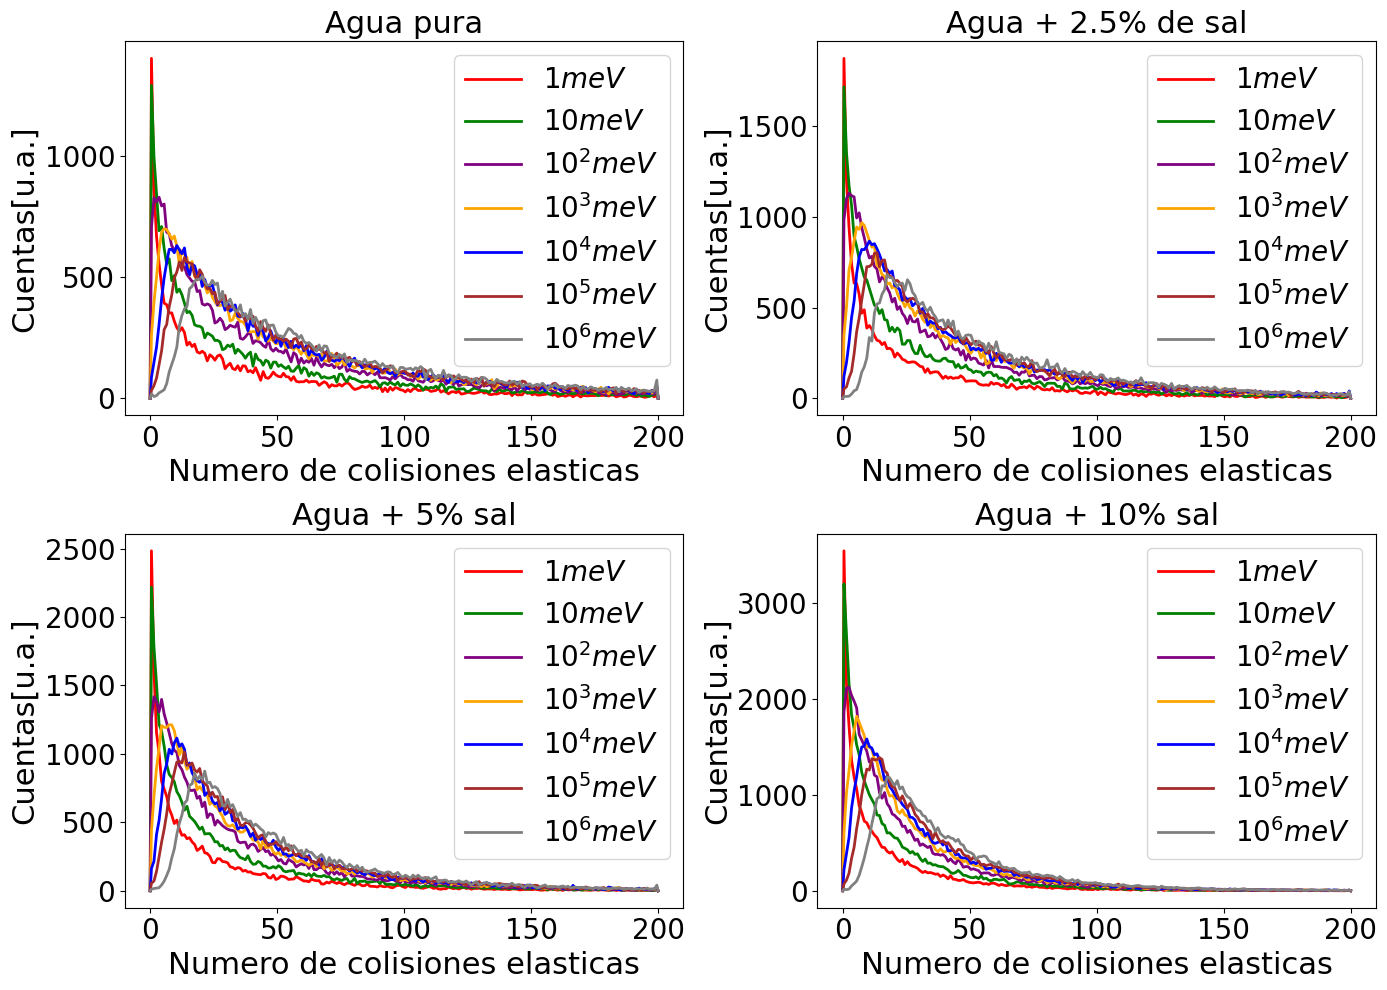

In [242]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# Función para calcular y graficar polígonos de frecuencia como línea continua
#def plot_polygon(ax, data, color, label):
#    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
#    bin_centers = (bins[:-1] + bins[1:]) / 2  
#    ax.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

def plot_polygon(ax, data, color, label):
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Insertar extremos en 0 y 200 con valor 0
    x = np.concatenate(([inicio], bin_centers, [fin]))
    y = np.concatenate(([0], counts, [0]))
    
    ax.plot(x, y, linestyle='-', color=color, label=label, linewidth=2)



# Crear figura con 4 subgráficos en una matriz 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Definir los conjuntos de datos y títulos de cada subgráfico
datos = [
    ([
        datos_n_AP_1meV, datos_n_AP_10meV, datos_n_AP_100meV,
        datos_n_AP_1000meV, datos_n_AP_10000meV, datos_n_AP_100000meV, datos_n_AP_1000000meV
    ], "Agua pura"),
    ([
        datos_n_A_25NaCl_1meV, datos_n_A_25NaCl_10meV, datos_n_A_25NaCl_100meV,
        datos_n_A_25NaCl_1000meV, datos_n_A_25NaCl_10000meV, datos_n_A_25NaCl_100000meV, datos_n_A_25NaCl_1000000meV
    ], "Agua + 2.5% de sal"),
    ([
        datos_n_A_5NaCl_1meV, datos_n_A_5NaCl_10meV, datos_n_A_5NaCl_100meV,
        datos_n_A_5NaCl_1000meV, datos_n_A_5NaCl_10000meV, datos_n_A_5NaCl_100000meV, datos_n_A_5NaCl_1000000meV
    ], "Agua + 5% sal"),
    ([
        datos_n_A_10NaCl_1meV, datos_n_A_10NaCl_10meV, datos_n_A_10NaCl_100meV,
        datos_n_A_10NaCl_1000meV, datos_n_A_10NaCl_10000meV, datos_n_A_10NaCl_100000meV, datos_n_A_10NaCl_1000000meV
    ], "Agua + 10% sal")
]

colores = ['red', 'green', 'purple', 'orange', 'blue', 'brown', 'grey']
#labels = ['1 meV', '10 meV', '100 meV', '1000 meV', '10000 meV', '100000 meV', '1000000 meV']
labels = ['$1 meV$', '$10 meV$', '$10^2 meV$', '$10^3 meV$', '$10^4 meV$', '$10^5 meV$', '$10^6 meV$']

# Graficar en cada subgráfico
for ax, (data_sets, title) in zip(axs.flatten(), datos):
    for i, (data, color) in enumerate(zip(data_sets, colores)):
        plot_polygon(ax, data, color=color, label=f'{labels[i]}')
    
    ax.set_title(title, fontsize=22)
    ax.set_xlabel('Numero de colisiones elasticas', fontsize=22)
    ax.set_ylabel('Cuentas[u.a.]', fontsize=22)
    #ax.set_yscale('log')  # Escala logarítmica
    #ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)  # Ajusta tamaño de los números en los ejes

# Ajustar diseño y guardar la figura
plt.tight_layout()
plt.savefig('Matriz_NC_Total_Agua_NaCl.jpg', format='jpg')
plt.savefig('Matriz_NC_Total_Agua_NaCl.pdf', format='pdf')
plt.show()


In [77]:
import matplotlib.pyplot as plt
import numpy as np
num_bins_n_AP = int(math.sqrt(len(datos_n_AP)))
num_bins_n_25NaCl = int(math.sqrt(len(datos_n_25NaCl)))
num_bins_n_5NaCl = int(math.sqrt(len(datos_n_5NaCl)))
num_bins_n_10NaCl = int(math.sqrt(len(datos_n_10NaCl)))
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].hist(datos_n_AP, bins=100,histtype='step', lw=1.0,edgecolor='red', log=True)
#parametros_histograma_1 = {'min': -5, 'max': 5, 'bins': 20, 'color': 'blue', 'label': 'Histograma 1'}
axs[0, 0].hist(datos_n_AP, bins=num_bins_n_AP,histtype='step', lw=1.0,edgecolor='red', log=True)
axs[0, 0].set_title('Agua pura')
axs[0, 0].set_xlabel('Número de Foto-electrones')
axs[0, 0].set_ylabel('Cuentas')
axs[0, 0].grid(True)
num_entries = len(datos_n_AP)
mean = sum(datos_n_AP) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_AP) / num_entries)
info_text = f'Agua Pura + N \nN° entradas: {num_entries}'
axs[0, 0].text(0.5, 0.5, f'N° entradas: {num_entries}', fontsize=12, ha='center', va='center', transform=axs[0, 0].transAxes)

axs[0, 1].hist(datos_n_25NaCl, bins=num_bins_n_25NaCl,histtype='step', lw=1.0,edgecolor='green', log=True)
axs[0, 1].set_title('Agua pura + 2.5 % de sal')
axs[0, 1].set_xlabel('Número de Foto-electrones')
axs[0, 1].set_ylabel('Cuentas')
axs[0, 1].grid(True)
num_entries = len(datos_n_25NaCl)
mean = sum(datos_n_25NaCl) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
axs[0, 1].text(0.5, 0.5, f'N° entradas: {num_entries}', fontsize=12, ha='center', va='center', transform=axs[0, 1].transAxes)


axs[1, 0].hist(datos_n_5NaCl, bins=num_bins_n_5NaCl,histtype='step', lw=1.0,edgecolor='purple', log=True)
axs[1, 0].set_title('Agua pura + 5 % de sal')
axs[1, 0].set_xlabel('Número de Foto-electrones')
axs[1, 0].set_ylabel('Cuentas')
axs[1, 0].grid(True)
num_entries = len(datos_n_5NaCl)
mean = sum(datos_n_5NaCl) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_5NaCl) / num_entries)
axs[1, 0].text(0.5, 0.5, f'N° entradas: {num_entries}', fontsize=12, ha='center', va='center', transform=axs[1, 0].transAxes)


axs[1, 1].hist(datos_n_10NaCl, bins=num_bins_n_10NaCl,histtype='step', lw=1.0,edgecolor='orange', log=True)
axs[1, 1].set_title('Agua pura + 10 % de sal')
axs[1, 1].set_xlabel('Número de Foto-electrones')
axs[1, 1].set_ylabel('Cuentas')
axs[1, 1].grid(True)
num_entries = len(datos_n_10NaCl)
mean = sum(datos_n_10NaCl) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)
axs[1, 1].text(0.5, 0.5, f'N° entradas: {num_entries}', fontsize=12, ha='center', va='center', transform=axs[1, 1].transAxes)
pdf_filename_stat_charge = 'Carga_Total_Agua_10NaCl.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Histogramas-Carga-Total_Agua-10NaCl.jpg', format='jpg')
#plt.tight_layout()
plt.show()


NameError: name 'datos_n_AP' is not defined

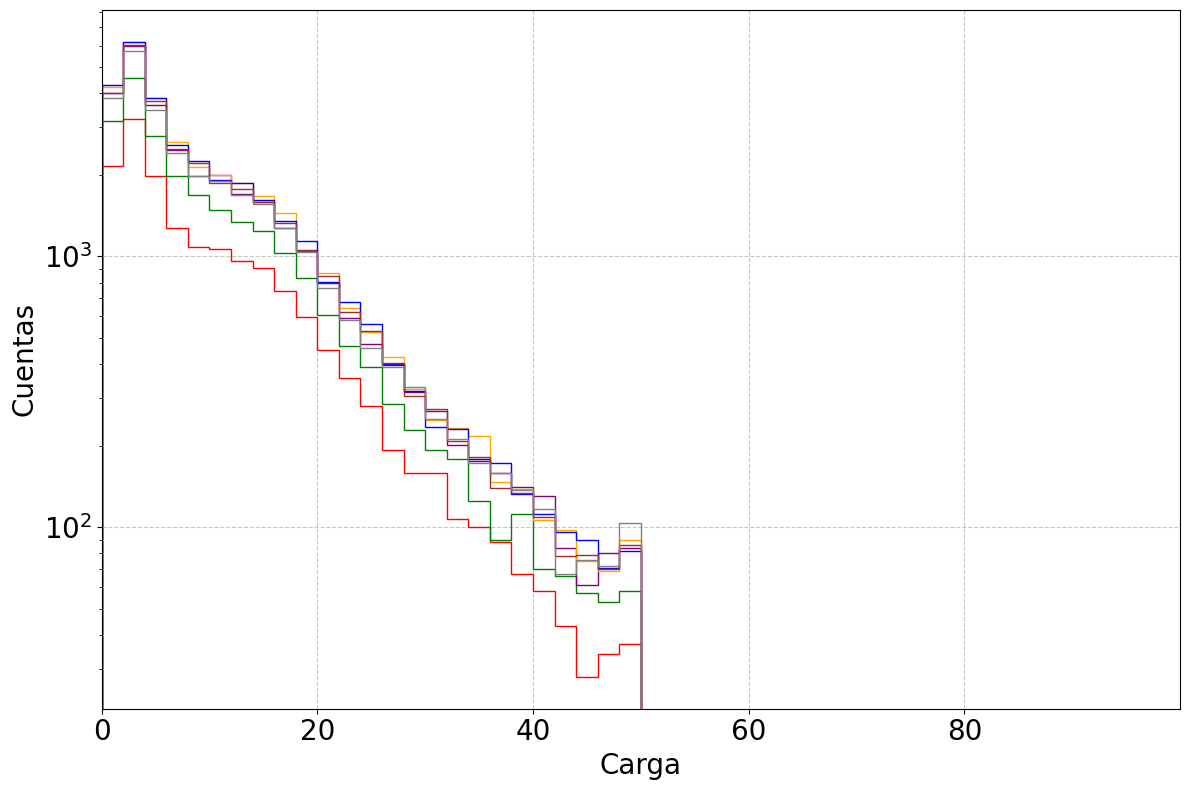

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
num_bins_n_A_10NaCl_1meV = int(math.sqrt(len(datos_n_A_10NaCl_1meV)))
num_bins_n_A_10NaCl_10meV = int(math.sqrt(len(datos_n_A_10NaCl_10meV)))
num_bins_n_A_10NaCl_100meV = int(math.sqrt(len(datos_n_A_10NaCl_100meV)))
num_bins_n_A_10NaCl_1000meV = int(math.sqrt(len(datos_n_A_10NaCl_1000meV)))
num_bins_n_A_10NaCl_10000meV = int(math.sqrt(len(datos_n_A_10NaCl_10000meV)))
num_bins_n_A_10NaCl_100000meV = int(math.sqrt(len(datos_n_A_10NaCl_100000meV)))
num_bins_n_A_10NaCl_1000000meV = int(math.sqrt(len(datos_n_A_10NaCl_1000000meV)))

numero_bins=25
inicio=0
fin=50
plt.figure(figsize=(12, 8))
plt.hist(datos_n_A_10NaCl_1meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='red', alpha=1.0, log=True)
#num_entries = len(datos_n_AP)
#mean = sum(datos_n_AP) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_AP) / num_entries)
#stats_text_charge = f'Agua Pura\n Entradas: {num_entries}\nMean: {mean:.2f}\nRMS: {std_dev:.2f}'
#stats_text_charge = f'Agua Pura\nEntradas: {num_entries}'
#plt.text(0.83, 0.89, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))
#plt.text(0.78, 0.91, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.93  # Posición de la línea en el eje y (ligeramente debajo del texto)
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='red', linewidth=4)

plt.hist(datos_n_A_10NaCl_10meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='green', alpha=1.0, log=True)
#num_entries = len(datos_n_25NaCl)
#mean = sum(datos_n_25NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
#stats_text_charge = f'Agua + 2.5 % de sal\nEntradas: {num_entries}'
#plt.text(0.83, 0.83, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='green', alpha=0.5))
#plt.text(0.78, 0.83, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.85  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='green', linewidth=4)

plt.hist(datos_n_A_10NaCl_100meV,bins=numero_bins, histtype='step', range=(inicio, fin), lw=1.0,edgecolor='purple', log=True)
#num_entries = len(datos_n_5NaCl)
#mean = sum(datos_n_5NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_5NaCl) / num_entries)
#stats_text_charge = f'Agua + 5 % de sal \nEntradas: {num_entries}'
#plt.text(0.78, 0.75, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.77  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='purple', linewidth=4)


#plt.text(0.80, 0.77, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='purple', alpha=0.5))


plt.hist(datos_n_A_10NaCl_1000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='orange', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)

plt.hist(datos_n_A_10NaCl_10000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='blue', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)


plt.hist(datos_n_A_10NaCl_100000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='brown', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)
#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'

plt.hist(datos_n_A_10NaCl_1000000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='grey', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)
#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'

# Agregar el texto
#plt.text(0.78, 0.68, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')

# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.71  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='orange', linewidth=4)

# Crear segmentos de línea para las leyendas
#linea_color_1 = Line2D([0], [0], color='red', lw=2)
#linea_color_2 = Line2D([0], [0], color='green', lw=2)
#linea_color_3 = Line2D([0], [0], color='purple', lw=2)
#linea_color_4 = Line2D([0], [0], color='orange', lw=2)

# Agregar leyendas una debajo de otra
#plt.legend([linea_color_1, linea_color_2, linea_color_3, linea_color_4],
#           ['Agua pura', 'Agua + 2.5 % de sal', 'Agua + 5 % de sal', 'Agua + 10 % de sal'],
#           loc='upper right',fontsize=14)


#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'
#plt.text(0.83, 0.71, stats_text_charge, transform=plt.gca().transAxes,fontsize=14, fontweight='bold', fontstyle='italic',bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))


#plt.text(0.83, 0.71, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))


#plt.hist(datos_n_25NaCl,bins=num_bins, histtype='step', range=(inicio, fin), color='orange', alpha=0.9, log=True)
plt.title('')
plt.xlabel('Carga', fontsize=20)
plt.ylabel('Cuentas', fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
plt.xlim(0, 100)
plt.xticks(np.arange(0, 100, 20))

plt.grid(True)
#num_entries = len(datos_n_25NaCl)
#mean = sum(datos_n_25NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
#stats_text_charge = f'Agua con N. a 500 MeV\nEntradas: {num_entries}\nMean: {mean:.2f}\nRMS: {std_dev:.2f}'
#plt.text(0.83, 0.33, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))

pdf_filename_diff_25 = 'Comparacion-Histogramas-carga-Neutrones-Exterior-TA-80H.pdf'
plt.savefig('Comparacion-Histogramas-carga-Neutrones-Exterior-TA-80H.jpg', format='jpg')
plt.savefig(pdf_filename_diff_25, format='pdf')
plt.tight_layout()
plt.show()


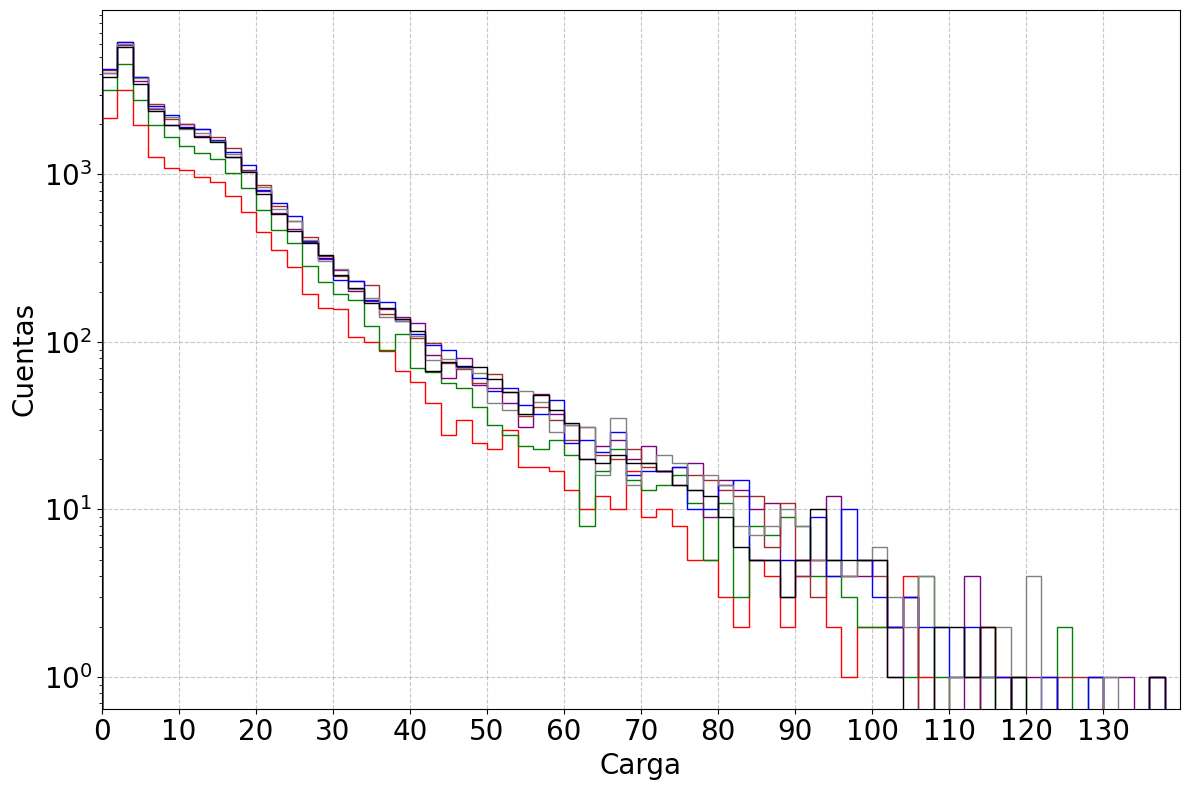

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

num_bins_n_A_10NaCl_1meV = int(math.sqrt(len(datos_n_A_10NaCl_1meV)))
num_bins_n_A_10NaCl_10meV = int(math.sqrt(len(datos_n_A_10NaCl_10meV)))
num_bins_n_A_10NaCl_100meV = int(math.sqrt(len(datos_n_A_10NaCl_100meV)))
num_bins_n_A_10NaCl_1000meV = int(math.sqrt(len(datos_n_A_10NaCl_1000meV)))
num_bins_n_A_10NaCl_10000meV = int(math.sqrt(len(datos_n_A_10NaCl_10000meV)))
num_bins_n_A_10NaCl_100000meV = int(math.sqrt(len(datos_n_A_10NaCl_100000meV)))
num_bins_n_A_10NaCl_1000000meV = int(math.sqrt(len(datos_n_A_10NaCl_1000000meV)))


#num_bins_n_10NaCl = int(math.sqrt(len(datos_n_10NaCl)))

numero_bins=100
inicio=0
fin=200
plt.figure(figsize=(12, 8))

plt.hist(datos_n_A_10NaCl_1meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='red', alpha=1.0, log=True)
#num_entries = len(datos_n_AP)
#mean = sum(datos_n_AP) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_AP) / num_entries)
#stats_text_charge = f'Agua Pura\n Entradas: {num_entries}\nMean: {mean:.2f}\nRMS: {std_dev:.2f}'
#stats_text_charge = f'Agua Pura\nEntradas: {num_entries}'
#plt.text(0.83, 0.89, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))
#plt.text(0.78, 0.91, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.93  # Posición de la línea en el eje y (ligeramente debajo del texto)
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='red', linewidth=4)

plt.hist(datos_n_A_10NaCl_10meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='green', alpha=1.0, log=True)
#num_entries = len(datos_n_25NaCl)
#mean = sum(datos_n_25NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
#stats_text_charge = f'Agua + 2.5 % de sal\nEntradas: {num_entries}'
#plt.text(0.83, 0.83, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='green', alpha=0.5))
#plt.text(0.78, 0.83, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.85  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='green', linewidth=4)

plt.hist(datos_n_A_10NaCl_100meV,bins=numero_bins, histtype='step', range=(inicio, fin), lw=1.0,edgecolor='purple', log=True)
#num_entries = len(datos_n_5NaCl)
#mean = sum(datos_n_5NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_5NaCl) / num_entries)
#stats_text_charge = f'Agua + 5 % de sal \nEntradas: {num_entries}'
#plt.text(0.78, 0.75, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.77  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='purple', linewidth=4)


#plt.text(0.80, 0.77, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='purple', alpha=0.5))


plt.hist(datos_n_A_10NaCl_1000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='brown', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)


plt.hist(datos_n_A_10NaCl_10000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='blue', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)


plt.hist(datos_n_A_10NaCl_100000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='grey', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)


plt.hist(datos_n_A_10NaCl_1000000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='black', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)

#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'

# Agregar el texto
#plt.text(0.78, 0.68, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')

# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.71  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='orange', linewidth=4)

# Crear segmentos de línea para las leyendas
#linea_color_1 = Line2D([0], [0], color='red', lw=2)
#linea_color_2 = Line2D([0], [0], color='green', lw=2)
#linea_color_3 = Line2D([0], [0], color='purple', lw=2)
#linea_color_4 = Line2D([0], [0], color='orange', lw=2)

# Agregar leyendas una debajo de otra
#plt.legend([linea_color_1, linea_color_2, linea_color_3],['Agua + 2.5 % de sal a 100 eV', 'Agua + 2.5 % de sal a 1KeV', 'Agua + 2.5 % de sal a 10eV'],loc='upper right',fontsize=14)


# Agregar leyendas una debajo de otra
#plt.legend([linea_color_1, linea_color_2, linea_color_3, linea_color_4],
#           ['Agua pura', 'Agua + 2.5 % de sal', 'Agua + 5 % de sal', 'Agua + 10 % de sal'],
#           loc='upper right',fontsize=14)


#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'
#plt.text(0.83, 0.71, stats_text_charge, transform=plt.gca().transAxes,fontsize=14, fontweight='bold', fontstyle='italic',bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))


#plt.text(0.83, 0.71, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))


#plt.hist(datos_n_25NaCl,bins=num_bins, histtype='step', range=(inicio, fin), color='orange', alpha=0.9, log=True)
plt.title('')
plt.xlabel('Carga', fontsize=20)
plt.ylabel('Cuentas', fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
plt.xlim(0, 140)
plt.xticks(np.arange(0, 140, 10))

plt.grid(True)
#num_entries = len(datos_n_25NaCl)
#mean = sum(datos_n_25NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
#stats_text_charge = f'Agua con N. a 500 MeV\nEntradas: {num_entries}\nMean: {mean:.2f}\nRMS: {std_dev:.2f}'
#plt.text(0.83, 0.33, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))

pdf_filename_diff_25 = 'Comparacion-Histogramas-carga-Neutrones-Exterior-TA-80H.pdf'
plt.savefig('Comparacion-Histogramas-carga-Neutrones-Exterior-TA-80H.jpg', format='jpg')
plt.savefig(pdf_filename_diff_25, format='pdf')
plt.tight_layout()
plt.show()


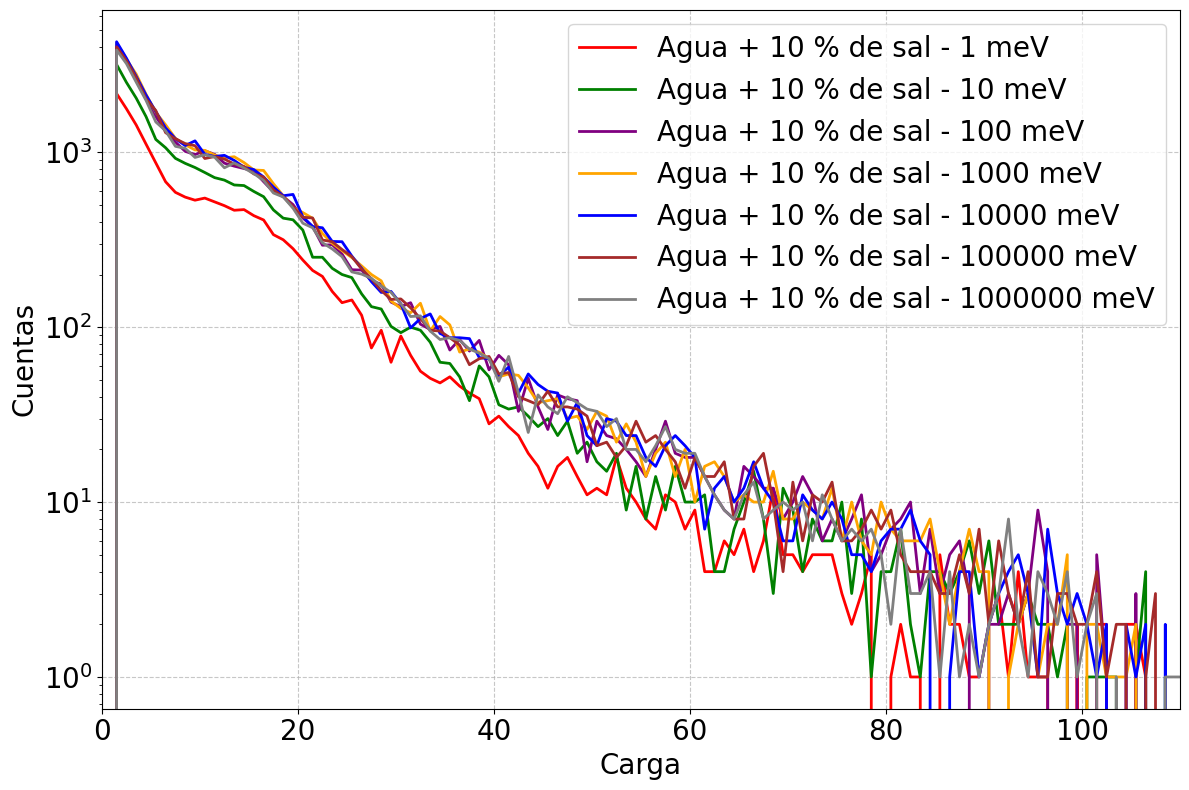

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_A_10NaCl_1meV, color='red', label='Agua + 10 % de sal - 1 meV')
plot_polygon(datos_n_A_10NaCl_10meV, color='green', label='Agua + 10 % de sal - 10 meV')
plot_polygon(datos_n_A_10NaCl_100meV, color='purple', label='Agua + 10 % de sal - 100 meV')
plot_polygon(datos_n_A_10NaCl_1000meV, color='orange', label='Agua + 10 % de sal - 1000 meV')
plot_polygon(datos_n_A_10NaCl_10000meV, color='blue', label='Agua + 10 % de sal - 10000 meV')
plot_polygon(datos_n_A_10NaCl_100000meV, color='brown', label='Agua + 10 % de sal - 100000 meV')
plot_polygon(datos_n_A_10NaCl_1000000meV, color='grey', label='Agua + 10 % de sal - 1000000 meV')

# Agregar etiquetas y formato
plt.xlabel('Carga', fontsize=20)
plt.ylabel('Cuentas', fontsize=20)
plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 110)
plt.xticks(np.arange(0, 110, 20))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('Cambio-Carga-Agua-10NaCl.jpg', format='jpg')
plt.savefig('Cambio-Carga-Agua-10NaCl.pdf', format='pdf')
plt.show()
